# P2 banco v2: temporalidades cortas contra el modelo D

**Qué es este cuaderno.** La evaluación de seis variantes nuevas del P2 sistemático, el "banco v2". Cinco tienen
pesos fijados de antemano (2A a 2E) y una sale de un procedimiento automático (2F). Todas usan las mismas reglas
que el modelo D, pero leen temporalidades más cortas: 1D, 2H, 1H, 30M y 5M.

**Para qué sirve.** Para decidir una sola cosa: si alguna de esas variantes debe reemplazar a D como el P2
sistemático que se imprime de referencia después de "Confirm & Save". P2 sigue siendo manual.

**Cómo leerlo.** La sección 0 es el resumen para decidir. El resto es la evidencia, en el orden en que conviene
leerla. Cada sección cierra con un **Resumen ejecutivo**.

**Tres cosas para tener presentes:**
- **Las reglas se fijaron antes de calcular.** Están en `jupyter/p2_banco_v2/preregistro.md`. La sección 2 muestra su
  sha256 y sus commits.
- **Todo resultado de acá es exploratorio.** Son los mismos análisis con los que ya se evaluó el banco v1
  (`p2_edge_evaluation.ipynb`). La evidencia independiente van a ser los análisis nuevos.
- **Nada está copiado a mano.** Cada tabla, cada gráfico y cada resumen se recalcula al ejecutar el cuaderno, desde
  las bases de datos (en solo lectura) y desde el banco de velas.

In [1]:
import glob, hashlib, math, os, subprocess, sys, warnings
warnings.filterwarnings("ignore")
from collections import Counter
from datetime import datetime, timedelta
from types import SimpleNamespace

ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "jupyter" else os.getcwd()
os.chdir(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import Markdown, display

from core.stats_tests import mcnemar_exact, n_required_one_sample
from tools.p2_backtest import MODEL_D, CsvOHLCProvider, calibrate_clock_offset, open_readonly_session
from tools import p2_bank_v2 as v2

# Dónde están los datos. Todo se lee en solo lectura; este worktree no tiene .data/.
DATA_DIR = os.environ.get("P2V2_DATA_DIR", "/home/jorgecg/projects/trading/blast_master/.data")
H2_DIR = os.environ.get("P2V2_H2_DIR", "/mnt/c/Users/jcifu/MT5Exports/p2_banco_v2")
OUT_DIR = os.path.join(ROOT, "jupyter", "p2_banco_v2")
ACCOUNTS = {"XAUUSD": "flight_account_001_xauusd.db", "BTCUSD": "flight_account_002_btcusdtp.db"}
DST_RULE = "us"                                    # BROKER_DST_RULE del .env del checkout principal
SEED, N_PERM, N_PERM_FINE = 20260929, 10_000, 100_000
LEADS = (0, 5, 10, 15, 20, 30, 60)                 # minutos antes de created_at (8.8)
LEAD = int(v2.ANCHOR_LEAD.total_seconds() // 60)   # 20: el ancla usada

# Paleta de referencia del skill de visualización, validada con su script (3 series, todos los pares).
INK, INK2, MUTED, GRIDC, AXIS, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA, BLUE_SOFT = "#2a78d6", "#eb6834", "#1baf7a", "#86b6ef"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF, "figure.dpi": 110,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": INK2,
    "axes.edgecolor": AXIS, "axes.grid": True, "grid.color": GRIDC, "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.family": "sans-serif", "font.size": 10, "axes.titlesize": 11.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "axes.axisbelow": True,
})
pd.set_option("display.max_colwidth", 220)
pd.set_option("display.max_rows", 200)


def md(text):
    display(Markdown(text))


def pct(x, d=0):
    return "—" if x is None or (isinstance(x, float) and math.isnan(x)) else f"{x * 100:.{d}f}%"


def pv(p):
    return "—" if p is None else ("<0.001" if p < 0.001 else f"{p:.3f}")


def frac(st):
    return "—" if st.bets == 0 else f"{st.hits}/{st.bets} = {st.accuracy * 100:.0f}%"


def ic(st):
    if st.bets == 0:
        return ""
    lo, hi = st.ci
    return f"[{lo * 100:.0f}–{hi * 100:.0f}]"


def celda(st):
    """Aciertos, porcentaje e IC95; avisa si no llega a 20 opiniones."""
    if st.bets == 0:
        return "no opina"
    return f"{frac(st)} {ic(st)}" + (" · muestra insuficiente" if st.insufficient else "")


def firmado(n):
    return f"{n:+d}"


def lista(items, y="y"):
    items = [str(i) for i in items]
    if len(items) <= 1:
        return "".join(items)
    return ", ".join(items[:-1]) + f" {y} " + items[-1]


def fecha(t):
    return pd.Timestamp(t).strftime("%Y-%m-%d %H:%M")


def miles(n):
    return f"{n:,}".replace(",", " ")


def mostrar(fig, alt):
    """Muestra la figura con texto alternativo (para lectores de pantalla) y la cierra."""
    display(fig, metadata={"image/png": {"alt": alt}})
    plt.close(fig)

In [2]:
# F2. Datos. Acá está toda la lectura de disco, siempre en solo lectura: las DBs con mode=ro
# (open_readonly_session), las velas del banco y el CSV del 2H. Aborta si algo no valida.
def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def cargar_cuenta(name, db_file):
    bank_dir = os.path.join(DATA_DIR, "candle_bank", name)
    provider = v2.BankProvider(bank_dir)
    provider.load_all(v2.BANK_TIMEFRAMES)            # una sola lectura: el snapshot de velas
    archivos = {tf: os.path.join(bank_dir, f"{tf}.csv") for tf in v2.BANK_TIMEFRAMES}

    runs = sorted(glob.glob(os.path.join(H2_DIR, name, "*", "2H.csv")))
    native = None
    if runs:                                         # el 2H se lee de la carpeta del export, no del banco
        archivos["2H"] = runs[-1]
        native = pd.read_csv(runs[-1])
        native.columns = [str(c).strip().lower() for c in native.columns]
        native["time"] = pd.to_datetime(native["time"])
        native = native.sort_values("time").reset_index(drop=True)

    manifest = pd.DataFrame([{
        "TF": tf, "filas": len(native if tf == "2H" else provider.frame(tf)),
        "primera": (native if tf == "2H" else provider.frame(tf))["time"].iloc[0],
        "última": (native if tf == "2H" else provider.frame(tf))["time"].iloc[-1],
        "archivo": path, "sha256": sha256_file(path),
    } for tf, path in archivos.items()])

    session = open_readonly_session(os.path.join(DATA_DIR, db_file))
    try:
        clock = calibrate_clock_offset(session, CsvOHLCProvider(bank_dir))
        entries = v2.reference_entries(session)
        records = v2.load_analyses(session, name)
    finally:
        session.close()
    if clock.aligned is not True:
        raise v2.StopCondition(f"{name}: el reloj del banco no valida. {clock.describe()}")
    fine_clock = {tf: v2.clock_check_tf(entries, provider, tf) for tf in ("1M", "5M")}
    if any(c.aligned is not True for c in fine_clock.values()):
        raise v2.StopCondition(f"{name}: 1M o 5M no validan el reloj.")

    dedup, h2 = v2.prepare_provider(provider, records, entries, native, DST_RULE)
    return SimpleNamespace(name=name, provider=provider, records=records, entries=entries, clock=clock,
                           fine_clock=fine_clock, dedup=dedup, h2=h2, manifest=manifest)


ACC = {name: cargar_cuenta(name, db) for name, db in ACCOUNTS.items()}

# F3-F4. Una fila por análisis: alcance, primer toque S1, etiqueta Overlap y snapshot de indicadores en el ancla.
ROWS = {name: v2.evaluate_account(acc.records, acc.provider) for name, acc in ACC.items()}

H2_LOST, D_MEASURED = v2.h2_loss_share({name: acc.provider for name, acc in ACC.items()}, ROWS)
if D_MEASURED and H2_LOST / D_MEASURED > v2.H2_STOP_THRESHOLD:
    raise v2.StopCondition(f"El 2H deja fuera {H2_LOST} de los {D_MEASURED} análisis que D mide (más del 25%).")

orden = lambda x: (x[1].scoped.anchor, x[1].scoped.rec.trade_id)
INS = sorted(((n, r) for n, rows in ROWS.items() for r in rows if r.in_scope), key=orden)   # en alcance
RES = [(n, r) for n, r in INS if r.resolved]                                                # resueltos por S1
N = len(RES)
truth = np.array([r.touch.direction for _, r in RES])
asset = np.array([n for n, _ in RES])
choppy = np.array([r.scoped.segment == v2.SEG_CHOPPY for _, r in RES])
directional = np.array([r.scoped.segment == v2.SEG_DIRECTIONAL for _, r in RES])
s4 = np.array([r.touch.within_s4 for _, r in RES])
SEG = {"Todos": np.ones(N, dtype=bool), "Direccionales": directional, "Choppy": choppy}

# Predicciones: +1 / -1 / 0 por análisis y modelo, con el mismo snapshot de velas para todos.
MODELS = {m.name: m for m in v2.FAMILY}
FULL = {name: [v2.predict_model(r.snapshots, m) for _, r in RES] for name, m in MODELS.items()}
PRED = {name: np.array([p.pred for p in ps]) for name, ps in FULL.items()}
COVER = {name: np.array([p.covered for p in ps]) for name, ps in FULL.items()}
DISC = v2.P2_DISC
PRED[DISC] = np.array([v2.sign_of(r.scoped.rec.p2_disc) for _, r in RES])
COVER[DISC] = np.array([r.scoped.rec.p2_disc is not None for _, r in RES])

In [3]:
# F5. 2F: grilla de 10 626 combinaciones, selección fuera de muestra y permutación del procedimiento.
GRID = v2.weight_grid()
CONTRIB, COVERED_2X = v2.contribution_matrix([r.snapshots for _, r in RES])
PG = v2.grid_predictions(CONTRIB, COVERED_2X, GRID)
for name, w in v2.WEIGHTS_2X.items():       # la grilla reproduce a 2A-2E exactamente
    assert (PG[:, v2.grid_index(GRID, w)] == PRED[name]).all(), name
PRIOR = v2.WEIGHTS_2X["2A"]
TWOF = v2.run_2f(PG, truth, GRID, PRIOR)
WF = TWOF.wf_mask                           # análisis de prueba del walk-forward
PRED["2F"], PRED["2F-LOO"] = TWOF.wf_pred, TWOF.loo_pred
COVER["2F"], COVER["2F-LOO"] = COVERED_2X & WF, COVERED_2X
PERM_2F = v2.permutation_2f(PG, truth, GRID, PRIOR, SEG, N_PERM, SEED)
PERM_2F_FINE = v2.permutation_2f(PG, truth, GRID, PRIOR, {"Todos": SEG["Todos"]}, N_PERM_FINE, SEED)["Todos"]
# Control: el mismo walk-forward, pero sin usar resultados que todavía no se conocían en el ancla de cada análisis.
KNOWN = v2.run_2f_known_outcomes(PG, truth, GRID, PRIOR, [r.scoped.anchor for _, r in RES],
                                 [r.touch.touch_time for _, r in RES], n_perm=N_PERM, seed=SEED)

# 8.1: familia de 13 variantes, con el p de cada modelo sacado del mismo nulo. También por segmento (Q3).
NETS, P81, NULL = {}, {}, {}
for seg, m in SEG.items():
    NETS[seg], P81[seg], NULL[seg] = v2.family_permutation({k: PRED[k][m] for k in MODELS}, truth[m], N_PERM, SEED)

X_FIXED = list(v2.NAMES_2X)                 # 2A a 2E
X_ALL = X_FIXED + ["2F"]
BEST = v2.best_of(PRED, truth)              # mejor 2X entre 2A y 2E
BEST_FAMILY = min(MODELS, key=lambda k: (-NETS["Todos"][k], list(MODELS).index(k)))


def base(name):
    """2F solo existe fuera de muestra: se mide en los análisis de prueba del walk-forward."""
    return WF if name == "2F" else np.ones(N, dtype=bool)


def stats(name, seg="Todos", extra=None):
    m = SEG[seg] & base(name)
    if extra is not None:
        m = m & extra
    return v2.predictor_stats(PRED[name], truth, m)


def pair(x, y, seg="Todos"):
    return v2.paired_compare(PRED[x], PRED[y], truth, SEG[seg] & base(x) & base(y))


def p81(name, seg="Todos"):
    return PERM_2F[seg][1] if name == "2F" else P81[seg][name]


LAB_D = {seg: {x: v2.label_vs_d(pair(x, "D", seg), p81(x, seg)) for x in X_ALL} for seg in SEG}
LAB_DISC = {seg: {x: v2.label_vs_disc(pair(x, DISC, seg), p81(x, seg)) for x in X_ALL} for seg in SEG}
PAIR_Q4 = pair("2A", "D-EQ")
LAB_Q4 = v2.label_single_comparison(PAIR_Q4)

# Q3: ¿cambia alguna etiqueta entre Direccionales y Choppy, con 20 pares o más en los dos?
Q3_COMPARABLE, Q3_CHANGES = 0, []
for labs, other in ((LAB_D, "D"), (LAB_DISC, DISC)):
    for x in X_ALL:
        if pair(x, other, "Direccionales").n >= v2.MIN_N and pair(x, other, "Choppy").n >= v2.MIN_N:
            Q3_COMPARABLE += 1
            if labs["Direccionales"][x] != labs["Choppy"][x]:
                Q3_CHANGES.append((x, other))
Q3 = "no concluyente" if Q3_COMPARABLE == 0 else ("sí" if Q3_CHANGES else "no")

# Acción recomendada (pre-registro §11).
SUPERAN = [x for x in X_ALL if LAB_D["Todos"][x] == v2.LABEL_SUPERA]
EVIDENCIA = {
    "D, binomial contra 50%": stats("D").p_binom,
    f"el mejor de la familia ({BEST_FAMILY}), corregido por las 13 variantes": P81["Todos"][BEST_FAMILY],
    "2F fuera de muestra, permutación del procedimiento": PERM_2F["Todos"][1],
}
if SUPERAN:
    ELEGIDO = min(SUPERAN, key=lambda x: (pair(x, "D").p, -(pair(x, "D").b - pair(x, "D").c)))
    ACCION, ACCION_TXT = "reemplazar", f"reemplazar D por {ELEGIDO}"
elif all(p >= v2.ALPHA for p in EVIDENCIA.values()):
    ELEGIDO, ACCION, ACCION_TXT = None, "cerrar", "cerrar la línea"
else:
    ELEGIDO, ACCION, ACCION_TXT = None, "mantener", "mantener D como feedback"
ACCION_MAY = ACCION_TXT[0].upper() + ACCION_TXT[1:]

# Cuántos desacuerdos hacen falta, como mínimo, para que un resultado unánime dé McNemar p < 0.05.
MIN_DESACUERDOS = next(k for k in range(1, 50) if mcnemar_exact(k, 0) < v2.ALPHA)
P_UNANIME = mcnemar_exact(MIN_DESACUERDOS, 0)

In [4]:
# R5. Pruebas de sobreajuste sobre el mejor 2X (pre-registro §9).
HALF = N // 2
primera = np.arange(N) < HALF
MITADES = {"1ª mitad": primera, "2ª mitad": ~primera}

# 8.4: vecinos de los pesos del mejor 2X en la grilla.
BEST_W = v2.WEIGHTS_2X[BEST]
BEST_NET_IS = int(TWOF.in_sample_net[v2.grid_index(GRID, BEST_W)])
VECINOS = [(w, int(TWOF.in_sample_net[v2.grid_index(GRID, w)])) for w in v2.grid_neighbors(BEST_W)]
VECINOS_CERCA = float(np.mean([net >= BEST_NET_IS - 2 for _, net in VECINOS]))

# 8.5: referencias ingenuas en los análisis donde el mejor 2X opina.
opina_best = PRED[BEST] != 0
K_BEST = int(((PRED[BEST] == truth) & opina_best).sum())
K_LONG, K_SHORT = int((truth[opina_best] == 1).sum()), int((truth[opina_best] == -1).sum())

# 8.7: momentos al azar de XAU, con niveles simétricos a la distancia típica de los tuyos.
xau_ins = [r for n, r in INS if n == "XAUUSD"]
BANDA = float(np.median([(abs(r.scoped.rec.evp - r.scoped.start_price) + abs(r.scoped.rec.si - r.scoped.start_price)) / 2
                         for r in xau_ins]))
XAU_A0, XAU_A1 = min(r.scoped.anchor for r in xau_ins), max(r.scoped.anchor for r in xau_ins)
AZAR_MODELOS = [MODELS[BEST], MODEL_D]
AZAR = {
    "cualquier hora": v2.random_moments(ACC["XAUUSD"].provider, XAU_A0, XAU_A1, BANDA, AZAR_MODELOS, SEED, 400),
    "5:00 a 8:59": v2.random_moments(ACC["XAUUSD"].provider, XAU_A0, XAU_A1, BANDA, AZAR_MODELOS, SEED, 400, hours=(5, 8)),
}


def azar_stats(grupo, modelo):
    df = AZAR[grupo]
    df = df[df["estado"] == v2.S1_RESOLVED]
    return v2.predictor_stats(df[modelo].to_numpy(dtype=int), df["verdad"].to_numpy(dtype=int))


en_xau = asset == "XAUUSD"
TUYOS = {m: stats(m, extra=en_xau) for m in (BEST, "D")}

# 8.8 geometría: ¿el acierto viene de que un nivel queda más cerca?
p0 = np.array([r.scoped.start_price for _, r in RES])
evp = np.array([r.scoped.rec.evp for _, r in RES])
si = np.array([r.scoped.rec.si for _, r in RES])
dist_v, dist_i = np.abs(evp - p0), np.abs(si - p0)
tesis = np.array([1 if r.scoped.thesis == "long" else -1 for _, r in RES])
ESPERADO_DIST = float(np.mean(dist_i / (dist_v + dist_i)))
CONFIRMADA = float(np.mean(truth == tesis))
cercano = np.where(dist_v < dist_i, np.sign(evp - p0), np.sign(si - p0)).astype(int)
GEO = {
    "Siempre la dirección de tu tesis": v2.predictor_stats(tesis, truth),
    "Siempre hacia el nivel más cercano": v2.predictor_stats(cercano, truth),
    f"{BEST}, todas sus opiniones": stats(BEST),
    f"{BEST} cuando apunta al nivel más cercano": stats(BEST, extra=PRED[BEST] == cercano),
    f"{BEST} cuando apunta al nivel más lejano": stats(BEST, extra=PRED[BEST] == -cercano),
}
LEJANO = GEO[f"{BEST} cuando apunta al nivel más lejano"]

# 8.8 ancla: todo recalculado con el ancla a 0..60 minutos de created_at.
TF_SWEEP = sorted(set(MODELS[BEST].timeframes) | set(MODEL_D.timeframes))
SWEEP, SWEEP_TRUTH = {}, {}
for lead in LEADS:
    filas = [(n, r) for n, acc in ACC.items()
             for r in v2.evaluate_account(acc.records, acc.provider, timedelta(minutes=lead), snapshot_timeframes=TF_SWEEP)
             if r.in_scope]
    res = [(n, r) for n, r in filas if r.resolved]
    t = np.array([r.touch.direction for _, r in res])
    SWEEP_TRUTH[lead] = {r.scoped.rec.trade_id: r.touch.direction for _, r in res}
    SWEEP[lead] = {"en alcance": len(filas), "resueltos": len(res)}
    for nombre, modelo in ((BEST, MODELS[BEST]), ("D", MODEL_D)):
        SWEEP[lead][nombre] = v2.predictor_stats(np.array([v2.predict_model(r.snapshots, modelo).pred for _, r in res]), t)
    SWEEP[lead][DISC] = v2.predictor_stats(np.array([v2.sign_of(r.scoped.rec.p2_disc) for _, r in res]), t)
REF = SWEEP[LEAD][BEST].accuracy
MAX_DESVIO = max(abs(SWEEP[l][BEST].accuracy - REF) for l in LEADS) * 100


def simbolo(ok, medio=False):
    return "✅" if ok else ("⚠️" if medio else "❌")


# Controles descriptivos (no entran en ninguna regla).
# (a) El primer toque medido con velas más gruesas: ¿cambia la verdad?
S1_ALT = {}
for etiqueta, tfs in {"15M": ("15M", "30M", "1H"), "1H": ("1H",)}.items():
    igual = distinto = sin_resolver = 0
    for n, r in RES:
        ft = v2.first_touch_s1(ACC[n].provider, r.scoped.anchor, r.scoped.rec.evp, r.scoped.rec.si, timeframes=tfs)
        if ft.state != v2.S1_RESOLVED:
            sin_resolver += 1
        elif ft.direction == r.touch.direction:
            igual += 1
        else:
            distinto += 1
    S1_ALT[etiqueta] = (igual, distinto, sin_resolver)

# (b) ¿Cambiaría alguna decisión del edge si P2 fuera el del modelo? Misma fórmula de producción.
SENTIDO = {"Bullish": 1, "Bearish": -1}
EDGE = {}
for nombre in ["D"] + X_FIXED:
    comparables = cambia = invierte = 0
    for (n, r), p in zip(RES, FULL[nombre]):
        e = v2.edge_with_p2(r.scoped.rec, p.rescaled)
        if e is None:
            continue
        comparables += 1
        nuevo = v2.determine_market_bias(e)
        if nuevo != r.scoped.bias_original:
            cambia += 1
            invierte += SENTIDO.get(nuevo, 0) * SENTIDO.get(r.scoped.bias_original, 0) == -1
    EDGE[nombre] = (comparables, cambia, invierte)
EDGE_NO_REPRODUCE = sum(abs(v2.edge_with_p2(r.scoped.rec, r.scoped.rec.p2_disc) - r.scoped.rec.calc_edge) > 1e-6
                        for _, r in RES if v2.edge_with_p2(r.scoped.rec, r.scoped.rec.p2_disc) is not None)

# (c) R3: ¿algún par de modelos comparte temporalidades, reglas y pesos?
firma = {m.name: (m.timeframes, m.ema_chain, m.use_di, tuple(round(m.weights[tf], 9) for tf in m.timeframes))
         for m in v2.FAMILY}
DUPLICADOS = [(a, b) for i, a in enumerate(firma) for b in list(firma)[i + 1:] if firma[a] == firma[b]]

In [5]:
# resultados.csv: análisis x modelo, para reanalizar sin volver a correr el cuaderno.
TFS = list(v2.MODEL_TIMEFRAMES)
FOLD_OF = {}
for k, f in enumerate(TWOF.folds):
    for i in range(*f["test"]):
        FOLD_OF[i] = f["weights"]


def fila_base(cuenta, row, i_res):
    sc, rec, t = row.scoped, row.scoped.rec, row.touch
    return {
        "cuenta": cuenta, "trade_id": rec.trade_id, "created_at": rec.created_at, "ancla": sc.anchor,
        "estado_alcance": sc.status, "precio_partida": sc.start_price, "tf_partida": sc.start_tf,
        "evp": rec.evp, "si": rec.si, "tesis": sc.thesis, "calc_edge": rec.calc_edge,
        "bias_original": sc.bias_original, "segmento": sc.segment,
        "s1_estado": t.state if t else None, "s1_nivel": t.level if t else None,
        "verdad": t.direction if t else None, "toque_hora": t.touch_time if t else None,
        "toque_tf": t.touch_tf if t else None, "horas_al_toque": round(t.hours, 4) if t and t.hours is not None else None,
        "s4": ("dentro" if t.within_s4 else "fuera") if t and t.state == v2.S1_RESOLVED else None,
        "overlap": row.overlap is not None if t else None, "overlap_b": row.overlap[0] if row.overlap else None,
        "p2_disc": rec.p2_disc,
    }


def acierto(pred, verdad):
    return None if not pred or verdad is None else int(pred == verdad)


registros = []
idx_res = {r.scoped.rec.trade_id: i for i, (_, r) in enumerate(RES)}
for cuenta, rows in ROWS.items():
    for row in rows:
        b = fila_base(cuenta, row, None)
        if not row.in_scope:
            registros.append({**b, "modelo": "(fuera de alcance)"})
            continue
        verdad = row.touch.direction
        for nombre, modelo in MODELS.items():
            p = v2.predict_model(row.snapshots, modelo)
            rec = {**b, "modelo": nombre, "cubierto": p.covered, "faltan_tf": " ".join(p.missing), "score": p.score,
                   "reescalado": p.rescaled, "prediccion": p.pred, "acierto": acierto(p.pred, verdad),
                   "pesos": " ".join(f"{tf}={w:.4g}" for tf, w in modelo.weights.items())}
            for tf in modelo.timeframes:
                rec[f"senal_{tf}"], rec[f"velas_{tf}"] = p.signals[tf], p.bars[tf]
            registros.append(rec)
        d = v2.sign_of(row.scoped.rec.p2_disc)
        registros.append({**b, "modelo": DISC, "cubierto": row.scoped.rec.p2_disc is not None,
                          "score": row.scoped.rec.p2_disc, "prediccion": d, "acierto": acierto(d, verdad)})
        i = idx_res.get(row.scoped.rec.trade_id)
        if i is not None:
            senales = {f"senal_{tf}": (CONTRIB[i, j] if COVERED_2X[i] else None) for j, tf in enumerate(v2.TIMEFRAMES_2X)}
            if WF[i]:
                w = FOLD_OF[i]
                registros.append({**b, **senales, "modelo": "2F", "cubierto": bool(COVERED_2X[i]),
                                  "prediccion": int(TWOF.wf_pred[i]), "acierto": acierto(int(TWOF.wf_pred[i]), verdad),
                                  "pesos": " ".join(f"{tf}={x:.4g}" for tf, x in zip(v2.TIMEFRAMES_2X, w))})
            w = GRID[TWOF.loo_idx[i]]
            registros.append({**b, **senales, "modelo": "2F-LOO", "cubierto": bool(COVERED_2X[i]),
                              "prediccion": int(TWOF.loo_pred[i]), "acierto": acierto(int(TWOF.loo_pred[i]), verdad),
                              "pesos": " ".join(f"{tf}={x:.4g}" for tf, x in zip(v2.TIMEFRAMES_2X, w))})

columnas = (list(fila_base("", RES[0][1], 0)) + ["modelo", "cubierto", "faltan_tf", "pesos", "score", "reescalado",
            "prediccion", "acierto"] + [f"senal_{tf}" for tf in TFS] + [f"velas_{tf}" for tf in TFS])
RESULTADOS = pd.DataFrame(registros).reindex(columns=columnas)
os.makedirs(OUT_DIR, exist_ok=True)
CSV_PATH = os.path.join(OUT_DIR, "resultados.csv")
RESULTADOS.to_csv(CSV_PATH, index=False)

# Pre-registro: sha256 y commits, para dejar constancia de que se fijó antes.
PREREG = os.path.join(OUT_DIR, "preregistro.md")
PREREG_SHA = sha256_file(PREREG)
try:
    PREREG_LOG = subprocess.run(["git", "log", "--format=%h|%cI|%s", "--", PREREG], capture_output=True, text=True,
                                cwd=ROOT, check=True).stdout.strip().splitlines()
except Exception:
    PREREG_LOG = []
PREREG_FECHA = datetime.fromisoformat(PREREG_LOG[0].split("|")[1]).replace(tzinfo=None) if PREREG_LOG else None
NUEVOS = (sum(r.created_at > PREREG_FECHA for acc in ACC.values() for r in acc.records) if PREREG_FECHA else None)

## 0. Resumen para decidir

In [6]:
pares_d = [pair(x, "D").n for x in X_FIXED]
total_disc = sum(pair(x, "D").n_disc for x in X_FIXED)
RANGO_PARES = f"{min(pares_d)} a {max(pares_d)}" if min(pares_d) != max(pares_d) else f"{pares_d[0]}"
st_best, st_d, st_disc = stats(BEST), stats("D"), stats(DISC)
etq_d = Counter(LAB_D["Todos"][x] for x in X_FIXED)
etq_disc = Counter(LAB_DISC["Todos"][x] for x in X_FIXED)


def por_etiqueta(labs, modelos):
    grupos = {}
    for x in modelos:
        grupos.setdefault(labs[x], []).append(x)
    return "; ".join(f"{lista(v)}: «{k}»" for k, v in grupos.items())


q1 = ("**Sí:** " + lista(SUPERAN) + "." if SUPERAN else "**No.**") + " " + por_etiqueta(LAB_D["Todos"], X_ALL) + ". "
q1 += (f"En los {RANGO_PARES} análisis donde un 2X y D opinan los dos, apuntan siempre para el mismo lado: no son señales "
       f"distintas, es la misma con otra cobertura." if total_disc == 0 else
       f"En los {RANGO_PARES} análisis donde un 2X y D opinan los dos, opinan distinto {total_disc} veces (sumando los cinco).")

supera_disc = [x for x in X_ALL if LAB_DISC["Todos"][x] == v2.LABEL_SUPERA]
iguala_disc = [x for x in X_ALL if LAB_DISC["Todos"][x] == v2.LABEL_EQUIVALENTE]
q2 = ("**Lo superan:** " + lista(supera_disc) + ". " if supera_disc else "**Ninguno lo supera.** ")
q2 += (f"{lista(iguala_disc)} lo igualan («equivalente»): la diferencia queda dentro del ruido de esta muestra. "
       if iguala_disc else "Ninguno queda «equivalente». ")
resto = [x for x in X_ALL if x not in supera_disc + iguala_disc]
q2 += (por_etiqueta(LAB_DISC["Todos"], resto) + "." if resto else "")

pares_choppy = [pair(x, o, "Choppy").n for x in X_ALL for o in ("D", DISC)]
q3 = {"no concluyente": f"**No se puede saber.** En Choppy ninguna comparación llega a {v2.MIN_N} pares (tienen entre "
                        f"{min(pares_choppy)} y {max(pares_choppy)}).",
      "sí": "**Sí:** cambia la etiqueta de " + lista([f"{x} contra {o}" for x, o in Q3_CHANGES]) + ".",
      "no": "**No.** Las etiquetas son las mismas en los dos segmentos."}[Q3]

q4 = {v2.LABEL_SUPERA: "**Mejora.**", v2.LABEL_INFERIOR: "**Empeora.**", v2.LABEL_NO_DISTINGUIBLE: "**No se distingue.**",
      v2.LABEL_NO_CONCLUYENTE: "**No concluyente.**"}[LAB_Q4]
q4 += (f" 2A contra D-EQ: {PAIR_Q4.n} pares, difieren en {PAIR_Q4.n_disc}"
       + (f" ({PAIR_Q4.b} a favor de 2A, {PAIR_Q4.c} a favor de D-EQ)" if PAIR_Q4.n_disc else "")
       + f". Por separado, 2A {frac(stats('2A'))} y D-EQ {frac(stats('D-EQ'))}.")

sobrevive = P81["Todos"][BEST] < v2.ALPHA
q5 = (("**Sí.**" if sobrevive else "**No.**") + f" El mejor 2X es {BEST} (neto {firmado(st_best.net)}). Corregido por haber probado "
      f"13 variantes, p = {pv(P81['Todos'][BEST])}. El mejor de las 13 es {BEST_FAMILY} (p = {pv(P81['Todos'][BEST_FAMILY])}).")

display(pd.DataFrame([
    {"Pregunta": "Q1. ¿Algún 2X supera a D?", "Respuesta corta": q1, "Dónde": "§5"},
    {"Pregunta": "Q2. ¿Algún 2X iguala o supera a tu P2 manual?", "Respuesta corta": q2, "Dónde": "§5"},
    {"Pregunta": "Q3. ¿Cambia algo entre Direccionales y Choppy?", "Respuesta corta": q3, "Dónde": "§4, §5"},
    {"Pregunta": "Q4. ¿Cambiar solo las temporalidades mejora o empeora?", "Respuesta corta": q4, "Dónde": "§5"},
    {"Pregunta": "Q5. ¿El mejor 2X sobrevive a la corrección por las 13 variantes?", "Respuesta corta": q5, "Dónde": "§7"},
]).style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"})
  .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))

sig = {k: p for k, p in EVIDENCIA.items() if p < v2.ALPHA}
texto = [f"### Acción recomendada: {ACCION_TXT}", ""]
if ACCION == "reemplazar":
    texto.append(f"{ELEGIDO} supera a D con la regla fijada de antemano (§5).")
else:
    texto.append("**Ningún 2X reemplaza a D.** La regla fijada de antemano exigía tres cosas a la vez: ganarle a D en los "
                 "análisis donde los dos opinan, que esa ventaja no se explique por suerte (McNemar p < 0.05) y "
                 "sobrevivir a la corrección por haber probado 13 variantes. Ninguno las cumple.")
    texto.append("")
    if ACCION == "mantener":
        texto.append("**Por qué «mantener D» y no «cerrar la línea».** La regla decía cerrar la línea solo si ningún P2 "
                     "sistemático mostraba acierto por encima del azar en tres pruebas. Una de las tres pasa:")
    else:
        texto.append("**Por qué «cerrar la línea».** Ningún P2 sistemático muestra acierto por encima del azar en "
                     "ninguna de las tres pruebas fijadas:")
    for k, p in EVIDENCIA.items():
        texto.append(f"- {k}: p = {pv(p)}" + (" ✅" if p < v2.ALPHA else ""))
    if ACCION == "mantener" and len(sig) == 1 and min(sig.values()) > 0.03:
        texto.append("")
        texto.append(f"**Ojo: es por un margen mínimo.** El único p por debajo de 0.05 es {pv(min(sig.values()))}. Con un "
                     f"p de 0.05 o más, la misma regla decía «cerrar la línea». Además, al mirar tres pruebas hay tres "
                     f"oportunidades de que una salga por suerte (§8). La lectura honesta es que la evidencia de que un P2 "
                     f"sistemático acierte más que una moneda sigue siendo débil.")
texto += ["", "**Los números que sostienen esto** (medidos desde el análisis, con el primer nivel que toca el precio):",
          f"- Análisis medidos: {N} ({int((asset == 'XAUUSD').sum())} de XAUUSD y {int((asset == 'BTCUSD').sum())} de BTC).",
          f"- D, el modelo actual: {celda(st_d)}, neto {firmado(st_d.net)}.",
          f"- {BEST}, el mejor 2X: {celda(st_best)}, neto {firmado(st_best.net)}.",
          f"- Tu P2 manual: {celda(st_disc)}, neto {firmado(st_disc.net)}.",
          ]
bajo_chop = [n for n in [DISC, "D"] + X_FIXED if stats(n, "Choppy").bets and stats(n, "Choppy").accuracy < 0.5]
if len(bajo_chop) == len([DISC, "D"] + X_FIXED):
    texto.append("- En los análisis Choppy, tu P2, D y los cinco 2X de pesos fijos quedan por debajo del 50%, con muy pocos "
                 "casos cada uno (§4).")
d_dir, b_dir = stats("D", "Direccionales"), stats(BEST, "Direccionales")
if min(P81["Direccionales"].values()) < v2.ALPHA:
    texto.append(f"- **El único indicio a favor, y es exploratorio:** en los análisis Direccionales, D acierta {frac(d_dir)} "
                 f"(p corregido por las 13 variantes = {pv(P81['Direccionales']['D'])}) y {BEST} {frac(b_dir)} "
                 f"(p = {pv(P81['Direccionales'][BEST])}). Ese p no corrige por haber mirado tres segmentos (§7).")
md("\n".join(texto))

margen = ACCION == "mantener" and len(sig) == 1 and min(sig.values()) > 0.03
md("### Resumen ejecutivo\n"
   + (f"{ELEGIDO} supera a D con la regla fijada de antemano, y la acción es {ACCION_TXT}." if ACCION == "reemplazar" else
      "El banco v2 no trae un modelo mejor que D"
      + (": en los análisis donde un 2X y D opinan los dos, dicen lo mismo. " if total_disc == 0 else ". ")
      + "Tampoco se distingue de tu P2 manual ni, con claridad, de una moneda. La acción que sale de la regla fijada de "
      + f"antemano es **{ACCION_TXT}**" + (", por un margen mínimo." if margen else ".")))

Pregunta,Respuesta corta,Dónde
Q1. ¿Algún 2X supera a D?,"**No.** 2A, 2B, 2C, 2D y 2E: «no distinguible»; 2F: «no concluyente». En los 26 a 30 análisis donde un 2X y D opinan los dos, apuntan siempre para el mismo lado: no son señales distintas, es la misma con otra cobertura.",§5
Q2. ¿Algún 2X iguala o supera a tu P2 manual?,"**Ninguno lo supera.** 2A, 2B, 2C, 2D y 2E lo igualan («equivalente»): la diferencia queda dentro del ruido de esta muestra. 2F: «no concluyente».",§5
Q3. ¿Cambia algo entre Direccionales y Choppy?,**No se puede saber.** En Choppy ninguna comparación llega a 20 pares (tienen entre 3 y 8).,"§4, §5"
Q4. ¿Cambiar solo las temporalidades mejora o empeora?,"**No se distingue.** 2A contra D-EQ: 23 pares, difieren en 0. Por separado, 2A 19/30 = 63% y D-EQ 22/39 = 56%.",§5
Q5. ¿El mejor 2X sobrevive a la corrección por las 13 variantes?,"**No.** El mejor 2X es 2D (neto +10). Corregido por haber probado 13 variantes, p = 0.213. El mejor de las 13 es D (p = 0.132).",§7


### Acción recomendada: mantener D como feedback

**Ningún 2X reemplaza a D.** La regla fijada de antemano exigía tres cosas a la vez: ganarle a D en los análisis donde los dos opinan, que esa ventaja no se explique por suerte (McNemar p < 0.05) y sobrevivir a la corrección por haber probado 13 variantes. Ninguno las cumple.

**Por qué «mantener D» y no «cerrar la línea».** La regla decía cerrar la línea solo si ningún P2 sistemático mostraba acierto por encima del azar en tres pruebas. Una de las tres pasa:
- D, binomial contra 50%: p = 0.073
- el mejor de la familia (D), corregido por las 13 variantes: p = 0.132
- 2F fuera de muestra, permutación del procedimiento: p = 0.047 ✅

**Ojo: es por un margen mínimo.** El único p por debajo de 0.05 es 0.047. Con un p de 0.05 o más, la misma regla decía «cerrar la línea». Además, al mirar tres pruebas hay tres oportunidades de que una salga por suerte (§8). La lectura honesta es que la evidencia de que un P2 sistemático acierte más que una moneda sigue siendo débil.

**Los números que sostienen esto** (medidos desde el análisis, con el primer nivel que toca el precio):
- Análisis medidos: 90 (68 de XAUUSD y 22 de BTC).
- D, el modelo actual: 25/38 = 66% [50–79], neto +12.
- 2D, el mejor 2X: 23/36 = 64% [48–78], neto +10.
- Tu P2 manual: 26/47 = 55% [41–69], neto +5.
- En los análisis Choppy, tu P2, D y los cinco 2X de pesos fijos quedan por debajo del 50%, con muy pocos casos cada uno (§4).
- **El único indicio a favor, y es exploratorio:** en los análisis Direccionales, D acierta 20/27 = 74% (p corregido por las 13 variantes = 0.031) y 2D 19/26 = 73% (p = 0.039). Ese p no corrige por haber mirado tres segmentos (§7).

### Resumen ejecutivo
El banco v2 no trae un modelo mejor que D: en los análisis donde un 2X y D opinan los dos, dicen lo mismo. Tampoco se distingue de tu P2 manual ni, con claridad, de una moneda. La acción que sale de la regla fijada de antemano es **mantener D como feedback**, por un margen mínimo.

## 1. Glosario mínimo

- **P2:** la parte de tu edge que mide tendencia y fuerza. La cargás a mano, de −2 a +2. Positivo dice "sube",
  negativo "baja" y 0 "no opino".
- **Modelo:** una receta fija que calcula un P2 a partir de las velas. En cada temporalidad mira si el precio y las
  medias móviles (EMA 20, 100 y 200) están ordenados hacia arriba o hacia abajo, si los indicadores de dirección (DI)
  lo confirman, y cuánta fuerza tiene el movimiento (ADX). Después pondera las temporalidades y lleva el resultado a
  la misma escala de −2 a +2.
- **D:** el modelo activo hoy. Lee 1W, 1D, 12H, 4H, 1H y 30M. **2A a 2E:** los candidatos nuevos, que leen 1D, 2H, 1H,
  30M y 5M con pesos fijados de antemano. **2F:** lo mismo, pero con los pesos elegidos por un procedimiento
  automático. **"2X"** es cualquiera de esos seis.
- **Tu P2 (P2-DISC):** el P2 que cargaste vos. **D-EQ:** las temporalidades de D con pesos iguales; sirve para separar el
  efecto de cambiar las temporalidades del de cambiar los pesos.
- **Opina:** un predictor opina cuando da una dirección. Si da 0, no opina, y ese análisis no cuenta ni como acierto
  ni como fallo.
- **Neto:** aciertos menos fallos. Premia acertar, castiga fallar, y no opinar suma 0.
- **Ancla:** el momento desde el que se mide. Es la hora del análisis, estimada como `created_at` menos 20 minutos.
- **Primer toque:** la "verdad" contra la que se mide. Es cuál de tus dos niveles toca primero el precio después del
  ancla: el de arriba o el de abajo. Se recorre con velas de 1 minuto.
- **Direccional / Choppy:** lo que dijo tu edge completo en ese análisis. Direccional es Bullish o Bearish. Choppy es
  que no apostó.
- **Par:** un análisis donde los dos predictores que se comparan opinan. Las comparaciones "pareadas" usan solo esos.
- **IC95 (intervalo):** el rango donde probablemente está el valor real. Con pocos casos es ancho: "64% [48–78]"
  quiere decir que el valor real puede estar en cualquier punto entre 48% y 78%.
- **p (p-valor):** qué tan seguido saldría un resultado así **por pura suerte**. Menos de 0.05 se toma como "difícil
  de explicar por suerte".
- **Fuera de muestra:** medir una receta en análisis que no se usaron para elegirla. Es la única forma honesta de
  evaluar algo que se eligió mirando datos.

### Resumen ejecutivo
Para leer el resto alcanzan tres ideas. Un predictor **opina** o no opina. Se lo juzga por cuántas veces acierta
cuando opina y por su **neto**. Y un resultado cuenta como evidencia solo si su **p** es menor que 0.05 **y** hay casos
suficientes (acá, 20 como mínimo).

## 2. Datos y controles

Antes de medir nada se verificaron cinco cosas: el reloj de las velas, que el banco no tenga velas repetidas, de dónde
sale el 2H, qué análisis entran y cuántas velas de historia tiene cada modelo.

In [7]:
md("### 2.1 Reloj de las velas")
filas = []
for name, acc in ACC.items():
    c = acc.clock
    fila = {"Cuenta": name, "Precios de referencia": c.n_entries,
            f"Caen en su vela de {c.timeframe}, sin desplazar": pct(c.rate_at_zero),
            "Mejor desplazamiento": f"{c.best_offset:+d} h"}
    for tf, fc in acc.fine_clock.items():
        fila[f"Mejor desplazamiento en {tf}"] = f"{fc.best_offset:+d} h"
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Cuenta"))
md("Una orden llenada o un Mark Price tiene que caer dentro del rango de la vela de ese momento. Si solo cuadrara "
   "corriendo las velas unas horas, las velas estarían en otro reloj y todo lo que viene después estaría mal. El mejor "
   "desplazamiento es 0 en todas las temporalidades: **el reloj está bien**.")

### 2.1 Reloj de las velas

,Precios de referencia,"Caen en su vela de 15M, sin desplazar",Mejor desplazamiento,Mejor desplazamiento en 1M,Mejor desplazamiento en 5M
Cuenta,,,,,
XAUUSD,105,78%,+0 h,+0 h,+0 h
BTCUSD,19,79%,+0 h,+0 h,+0 h


Una orden llenada o un Mark Price tiene que caer dentro del rango de la vela de ese momento. Si solo cuadrara corriendo las velas unas horas, las velas estarían en otro reloj y todo lo que viene después estaría mal. El mejor desplazamiento es 0 en todas las temporalidades: **el reloj está bien**.

In [8]:
md("### 2.2 Velas repetidas en el banco")
filas = []
for name, acc in ACC.items():
    for tf in v2.DUPLICATE_PRONE_TIMEFRAMES:
        d = acc.dedup[tf]
        filas.append({"Cuenta": name, "TF": tf, "Velas en el banco": d["antes"], "Pares repetidos": d["pares"],
                      "Sin resolver": d["sin_resolver"], "Velas usadas": d["después"]})
display(pd.DataFrame(filas).set_index(["Cuenta", "TF"]))
total_rep = sum(acc.dedup[tf]["pares"] for acc in ACC.values() for tf in v2.DUPLICATE_PRONE_TIMEFRAMES)
md(f"En 4H, 12H, 1D y 1W, el banco tenía cada vela de invierno **dos veces**: los mismos cuatro precios, con la hora "
   f"corrida una hora. Una copia vino de los CSV viejos (un solo reloj todo el año) y la otra del export nuevo (que en "
   f"invierno usa otro reloj). Se quitaron **{miles(total_rep)} copias** al leer, sin tocar el banco. Queda la que abre en "
   f"la hora correcta del servidor. Sin esta limpieza, las medias y el ADX de esas temporalidades veían cada día de "
   f"invierno dos veces.")

### 2.2 Velas repetidas en el banco

Velas en el banco  Pares repetidos  Sin resolver  Velas usadas
Cuenta TF                                                                 
XAUUSD 4H                2258              528             0          1730
       12H               1691              362             0          1329
       1D                1635              407             0          1228
       1W                1993              509             0          1484
BTCUSD 4H                2911              737             0          2174
       12H               2295              504             0          1791
       1D                2200              505             0          1695
       1W                1081              272             0           809

En 4H, 12H, 1D y 1W, el banco tenía cada vela de invierno **dos veces**: los mismos cuatro precios, con la hora corrida una hora. Una copia vino de los CSV viejos (un solo reloj todo el año) y la otra del export nuevo (que en invierno usa otro reloj). Se quitaron **3 824 copias** al leer, sin tocar el banco. Queda la que abre en la hora correcta del servidor. Sin esta limpieza, las medias y el ADX de esas temporalidades veían cada día de invierno dos veces.

In [9]:
md("### 2.3 De dónde sale el 2H")
filas = []
for name, acc in ACC.items():
    h = acc.h2
    fila = {"Cuenta": name, "Fuente usada": h.source}
    if h.clock is not None:
        fila["Reloj del 2H nativo"] = (("valida" if h.clock.aligned else "NO valida")
                                        + f" ({pct(h.clock.rate_at_zero)} sin desplazar; mejor {h.clock.best_offset:+d} h)")
        fila["Velas cerradas antes del primer análisis que D mide"] = f"{h.closed_at_first} (mínimo 800)"
        fila["Días hábiles seguidos sin velas"] = max((r[2] for r in h.gap_runs), default=0)
        fila["Nativo contra remuestreado: fronteras"] = pct(h.f2d["pct_fronteras_alineadas"], 1)
        fila["Nativo contra remuestreado: OHLC idéntico"] = f"{pct(h.f2d['pct_ohlc_identico'], 1)} de {h.f2d['comunes']} velas"
    fila["Control: 2H agregado a 4H contra el 4H del banco"] = f"{pct(h.control_4h['pct_ohlc_identico'], 1)} de {h.control_4h['comunes']} velas"
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Cuenta").T)
nativos = [n for n, a in ACC.items() if a.h2.source == v2.H2_NATIVE]
md((f"El banco no guarda 2H. Se exportó desde MT5 para este análisis y se leyó directo de la carpeta del export, sin "
    f"integrarlo al banco. **Se usó el 2H nativo en {lista(nativos)}**, porque cumple las tres condiciones fijadas: el "
    f"reloj valida, tiene más de 800 velas cerradas antes del primer análisis y no le faltan días. "
    if nativos else "No se pudo usar el 2H nativo; se armó desde el 1H del banco. ")
   + "Con velas de 2 horas, la prueba del reloj distingue mal un corrimiento de una hora: casi cualquier precio cae dentro "
     "de una vela tan ancha. Por eso en BTC, con 19 precios de referencia, un corrimiento de −1 h cuadra en 19 y sin "
     "corrimiento en 18; la regla lo da por válido (diferencia menor a 20 puntos). La prueba que decide es la segunda: se "
     "armó otro 2H juntando de a dos las velas de 1H del banco, que tienen el reloj verificado, y se compararon las dos "
     "series vela por vela. Coinciden en todas. Las diferencias del control contra el 4H son de borde: la primera vela "
     "del export y la del día del cambio de horario.")

### 2.3 De dónde sale el 2H

Cuenta,XAUUSD,BTCUSD
Fuente usada,nativo (F2b),nativo (F2b)
Reloj del 2H nativo,valida (95% sin desplazar; mejor +0 h),valida (95% sin desplazar; mejor -1 h)
Velas cerradas antes del primer análisis que D mide,1177 (mínimo 800),2079 (mínimo 800)
Días hábiles seguidos sin velas,0,0
Nativo contra remuestreado: fronteras,100.0%,100.0%
Nativo contra remuestreado: OHLC idéntico,100.0% de 1743 velas,100.0% de 1946 velas
Control: 2H agregado a 4H contra el 4H del banco,100.0% de 1164 velas,99.9% de 1375 velas


El banco no guarda 2H. Se exportó desde MT5 para este análisis y se leyó directo de la carpeta del export, sin integrarlo al banco. **Se usó el 2H nativo en XAUUSD y BTCUSD**, porque cumple las tres condiciones fijadas: el reloj valida, tiene más de 800 velas cerradas antes del primer análisis y no le faltan días. Con velas de 2 horas, la prueba del reloj distingue mal un corrimiento de una hora: casi cualquier precio cae dentro de una vela tan ancha. Por eso en BTC, con 19 precios de referencia, un corrimiento de −1 h cuadra en 19 y sin corrimiento en 18; la regla lo da por válido (diferencia menor a 20 puntos). La prueba que decide es la segunda: se armó otro 2H juntando de a dos las velas de 1H del banco, que tienen el reloj verificado, y se compararon las dos series vela por vela. Coinciden en todas. Las diferencias del control contra el 4H son de borde: la primera vela del export y la del día del cambio de horario.

In [10]:
md("### 2.4 Qué análisis entran")
filas = []
for name, rows in ROWS.items():
    c = Counter(r.scoped.status for r in rows)
    estados = Counter(r.touch.state for r in rows if r.in_scope)
    filas.append({
        "Cuenta": name, "Análisis en la DB": len(rows),
        "Fuera: sin nivel de validación o de invalidación": c[v2.EXCL_MISSING_LEVELS],
        "Fuera: retroactivos": c[v2.EXCL_BACKDATED],
        "Fuera: sin velas en ese momento": c[v2.EXCL_NO_HISTORY],
        "Fuera: los dos niveles del mismo lado del precio": c[v2.EXCL_LEVELS_SAME_SIDE],
        "En alcance": c[v2.IN_SCOPE],
        "Resueltos (tocó un nivel)": estados[v2.S1_RESOLVED],
        "Ambiguos (una vela de 1 min tocó los dos)": estados[v2.S1_AMBIGUOUS],
        "Sin toque todavía": estados[v2.S1_OPEN] + estados[v2.S1_PENDING],
        "Direccionales / Choppy": f"{sum(r.scoped.segment == v2.SEG_DIRECTIONAL for r in rows if r.resolved)} / "
                                  f"{sum(r.scoped.segment == v2.SEG_CHOPPY for r in rows if r.resolved)}",
        "Resueltos dentro de 48 h (S4)": sum(r.touch.within_s4 for r in rows if r.resolved),
        "Con etiqueta Overlap": sum(r.overlap is not None for r in rows if r.in_scope),
    })
display(pd.DataFrame(filas).set_index("Cuenta").T)
horas = np.array([r.touch.hours for _, r in RES])
q = np.percentile(horas, [50, 75, 90])
retro = sum(r.scoped.status == v2.EXCL_BACKDATED for rows in ROWS.values() for r in rows)
md(f"- **Retroactivos:** quedan fuera {retro}, porque se cargaron sabiendo lo que había pasado.\n"
   f"- **Dirección del primer toque:** {int((truth == 1).sum())} veces el nivel de arriba y {int((truth == -1).sum())} el de "
   f"abajo. El período estuvo equilibrado.\n"
   f"- **Cuánto tarda:** el precio toca un nivel en una mediana de {q[0]:.0f} horas; el 75% antes de {q[1]:.0f} h y el 90% "
   f"antes de {q[2]:.0f} h. {N - int(s4.sum())} análisis tardan más de 48 h y quedan fuera de la cifra secundaria S4.\n"
   f"- **Overlap** (hubo un análisis nuevo antes de que se resolviera el anterior) es solo una etiqueta: no saca ningún "
   f"análisis. La lista está en el anexo.\n"
   f"- **Precio de partida y primer toque:** los dos se midieron con velas de 1 minuto en todos los análisis.\n"
   + (f"- **¿Cambia algo por usar velas de 1 minuto?** No. Midiendo el primer toque con velas de 15 minutos, o con velas "
      f"de 1 hora como hacía el banco v1, la dirección es la misma en los {N} análisis."
      if S1_ALT["15M"][0] == N and S1_ALT["1H"][0] == N else
      f"- **¿Cambia algo por usar velas de 1 minuto?** Midiendo el primer toque con velas de 15 minutos, la dirección es la "
      f"misma en {S1_ALT['15M'][0]} de {N} análisis; cambia en {S1_ALT['15M'][1]} y queda sin resolver en "
      f"{S1_ALT['15M'][2]}. Con velas de 1 hora, como medía el banco v1: igual en {S1_ALT['1H'][0]}, cambia en "
      f"{S1_ALT['1H'][1]} y sin resolver en {S1_ALT['1H'][2]}. \"Sin resolver\" es que una misma vela toca los dos niveles "
      f"y no se sabe cuál fue primero."))

### 2.4 Qué análisis entran

Cuenta,XAUUSD,BTCUSD
Análisis en la DB,81,24
Fuera: sin nivel de validación o de invalidación,5,1
Fuera: retroactivos,7,0
Fuera: sin velas en ese momento,0,0
Fuera: los dos niveles del mismo lado del precio,1,1
En alcance,68,22
Resueltos (tocó un nivel),68,22
Ambiguos (una vela de 1 min tocó los dos),0,0
Sin toque todavía,0,0
Direccionales / Choppy,39 / 29,16 / 6


- **Retroactivos:** quedan fuera 7, porque se cargaron sabiendo lo que había pasado.
- **Dirección del primer toque:** 43 veces el nivel de arriba y 47 el de abajo. El período estuvo equilibrado.
- **Cuánto tarda:** el precio toca un nivel en una mediana de 11 horas; el 75% antes de 21 h y el 90% antes de 52 h. 11 análisis tardan más de 48 h y quedan fuera de la cifra secundaria S4.
- **Overlap** (hubo un análisis nuevo antes de que se resolviera el anterior) es solo una etiqueta: no saca ningún análisis. La lista está en el anexo.
- **Precio de partida y primer toque:** los dos se midieron con velas de 1 minuto en todos los análisis.
- **¿Cambia algo por usar velas de 1 minuto?** No. Midiendo el primer toque con velas de 15 minutos, o con velas de 1 hora como hacía el banco v1, la dirección es la misma en los 90 análisis.

In [11]:
md("### 2.5 Cuánta historia tiene cada modelo")
filas = []
for name, acc in ACC.items():
    ins = [r for n, r in INS if n == name]
    for tf in v2.MODEL_TIMEFRAMES:
        df = acc.provider.frame(tf)
        t800 = v2.first_time_with_closed(df, tf)
        sin = sum(acc.provider.n_closed(tf, r.scoped.anchor) < v2.MIN_BARS_PER_TF for r in ins)
        filas.append({"Cuenta": name, "TF": tf, "Velas": len(df), "Primera vela": fecha(df["time"].iloc[0]),
                      "Primera fecha con 800 velas cerradas": fecha(t800) if t800 is not None else "no llega",
                      "Análisis en alcance sin 800 velas": sin})
display(pd.DataFrame(filas).set_index(["Cuenta", "TF"]))

filas = []
for nombre in ["D", "A", "G", "D-EQ"] + X_FIXED:
    fila = {"Modelo": nombre, "Temporalidades": " ".join(MODELS[nombre].timeframes)}
    for name, acc in ACC.items():
        ins = [r for n, r in INS if n == name]
        faltan = Counter(tf for r in ins for tf in v2.model_coverage(acc.provider, MODELS[nombre], r.scoped.anchor)[1])
        sin = sum(not v2.model_coverage(acc.provider, MODELS[nombre], r.scoped.anchor)[0] for r in ins)
        fila[f"{name}: mide"] = f"{len(ins) - sin} de {len(ins)}"
        fila[f"{name}: motivo de los que pierde"] = ", ".join(f"{tf} ({k})" for tf, k in faltan.items()) or "—"
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Modelo"))
md(f"Un modelo necesita **800 velas cerradas** en cada temporalidad que lee. Si no las tiene, no opina en ese análisis. "
   f"El 2H deja fuera {H2_LOST} de los {D_MEASURED} análisis que D mide (el límite para detener el trabajo era 25%).")

### 2.5 Cuánta historia tiene cada modelo

Velas      Primera vela Primera fecha con 800 velas cerradas  \
Cuenta TF                                                                  
XAUUSD 1W    1484  1998-04-18 15:00                     2013-08-17 15:00   
       1D    1228  2021-12-26 16:00                     2025-01-30 16:00   
       12H   1329  2024-03-03 16:00                     2025-09-18 15:00   
       4H    1730  2025-08-17 15:00                     2026-02-23 00:00   
       2H    2326  2025-12-29 00:00                     2026-04-01 19:00   
       1H    3339  2026-03-08 16:00                     2026-04-27 10:00   
       30M   5696  2026-04-07 23:00                     2026-05-01 08:00   
       15M  10222  2026-04-26 16:00                     2026-05-07 08:00   
       5M   28710  2026-05-05 17:40                     2026-05-08 14:20   
BTCUSD 1W     809  2011-03-19 15:00                     2026-07-25 15:00   
       1D    1695  2022-02-06 16:00                     2024-04-16 15:00   
       12H   1791  2024-04-16 15:00                     2025-05-21 15:00   
       4H    2174  2025-10-01 19:00                     2026-02-12 04:00   
       2H    2742  2026-02-12 02:00                     2026-04-20 03:00   
       1H    3888  2026-04-19 17:00                     2026-05-23 02:00   
       30M   6160  2026-05-23 00:30                     2026-06-08 17:30   
       15M  10706  2026-06-08 16:15                     2026-06-17 01:15   
       5M   28886  2026-06-19 18:55                     2026-06-22 13:35   

            Análisis en alcance sin 800 velas  
Cuenta TF                                      
XAUUSD 1W                                   0  
       1D                                   0  
       12H                                  0  
       4H                                   0  
       2H                                   0  
       1H                                   0  
       30M                                  0  
       15M                                  0  
       5M                                   0  
BTCUSD 1W                                   7  
       1D                                   0  
       12H                                  0  
       4H                                   0  
       2H                                   0  
       1H                                   0  
       30M                                  0  
       15M                                  0  
       5M                                   0

,Temporalidades,XAUUSD: mide,XAUUSD: motivo de los que pierde,BTCUSD: mide,BTCUSD: motivo de los que pierde
Modelo,,,,,
D,1W 1D 12H 4H 1H 30M,68 de 68,—,15 de 22,1W (7)
A,1W 1D 12H 4H 1H,68 de 68,—,15 de 22,1W (7)
G,1W 1D 12H 4H 1H 30M 15M,68 de 68,—,15 de 22,1W (7)
D-EQ,1W 1D 12H 4H 1H 30M,68 de 68,—,15 de 22,1W (7)
2A,1D 2H 1H 30M 5M,68 de 68,—,22 de 22,—
2B,1D 2H 1H 30M 5M,68 de 68,—,22 de 22,—
2C,1D 2H 1H 30M 5M,68 de 68,—,22 de 22,—
2D,1D 2H 1H 30M 5M,68 de 68,—,22 de 22,—
2E,1D 2H 1H 30M 5M,68 de 68,—,22 de 22,—


Un modelo necesita **800 velas cerradas** en cada temporalidad que lee. Si no las tiene, no opina en ese análisis. El 2H deja fuera 0 de los 83 análisis que D mide (el límite para detener el trabajo era 25%).

In [12]:
md("### 2.6 El ancla: 20 minutos antes de `created_at` (el banco v1 usó 15)")
ids15, ids20 = SWEEP_TRUTH[15], SWEEP_TRUTH[LEAD]
comunes = set(ids15) & set(ids20)
cambian = sum(ids15[k] != ids20[k] for k in comunes)
display(pd.DataFrame([{
    "Ancla": f"created_at − {lead} min" + ("  ← la de este cuaderno" if lead == LEAD else "  ← la del banco v1"),
    "En alcance": SWEEP[lead]["en alcance"], "Resueltos": SWEEP[lead]["resueltos"],
    "D": celda(SWEEP[lead]["D"]), "Tu P2": celda(SWEEP[lead][DISC]), BEST: celda(SWEEP[lead][BEST]),
} for lead in (15, LEAD)]).set_index("Ancla"))
md(f"`created_at` se guarda al apretar \"Confirm & Save\", después de cargar P2. La hora real en que empezaste el análisis "
   f"no queda guardada, así que se estima restando 20 minutos (criterio del 2026-09-27). De 15 a 20 minutos, el nivel que "
   f"toca primero cambia en **{cambian} de {len(comunes)}** análisis. §7 repite la medición con anclas de 0 a 60 minutos.")

### 2.6 El ancla: 20 minutos antes de `created_at` (el banco v1 usó 15)

,En alcance,Resueltos,D,Tu P2,2D
Ancla,,,,,
created_at − 15 min ← la del banco v1,90,90,25/38 = 66% [50–79],26/47 = 55% [41–69],23/36 = 64% [48–78]
created_at − 20 min ← la de este cuaderno,90,90,25/38 = 66% [50–79],26/47 = 55% [41–69],23/36 = 64% [48–78]


`created_at` se guarda al apretar "Confirm & Save", después de cargar P2. La hora real en que empezaste el análisis no queda guardada, así que se estima restando 20 minutos (criterio del 2026-09-27). De 15 a 20 minutos, el nivel que toca primero cambia en **0 de 90** análisis. §7 repite la medición con anclas de 0 a 60 minutos.

In [13]:
md("### 2.7 El pre-registro y el snapshot de velas")
lineas = [f"- **Pre-registro:** `jupyter/p2_banco_v2/preregistro.md`, sha256 `{PREREG_SHA}`."]
for l in reversed(PREREG_LOG):
    h, f, s = l.split("|", 2)
    lineas.append(f"  - commit `{h}`, {f[:16].replace('T', ' ')}: {s}")
lineas.append(f"- **Análisis creados después del último commit del pre-registro:** {NUEVOS if NUEVOS is not None else 'no disponible'}. "
              "Son la evidencia independiente; todo lo demás es exploratorio.")
lineas.append("- **Velas usadas:** una sola lectura del banco (más el 2H del export), igual para todos los modelos. La "
              "tabla muestra las filas de cada archivo, antes de quitar las repetidas.")
lineas.append(f"- **Ejecutado:** {datetime.now():%Y-%m-%d %H:%M}, hora de Guatemala.")
md("\n".join(lineas))
man = pd.concat([acc.manifest.assign(Cuenta=name) for name, acc in ACC.items()])
man["sha256"] = man["sha256"].str[:16] + "…"
man["archivo"] = man["archivo"].str.replace(DATA_DIR, ".data", regex=False).str.replace(H2_DIR, "<export 2H>", regex=False)
display(man.set_index(["Cuenta", "TF"])[["filas", "primera", "última", "sha256", "archivo"]])

### 2.7 El pre-registro y el snapshot de velas

- **Pre-registro:** `jupyter/p2_banco_v2/preregistro.md`, sha256 `997a94165ba2918309e80c6b4d5814d5d43469fd397ff72fcb9740562529bcb6`.
  - commit `e99e69d`, 2026-09-29 11:24: P2 banco v2: pre-registration (F0), committed before computing any result
  - commit `c43f2b7`, 2026-09-30 06:45: P2 banco v2: pre-registration v1.1, committed before F3
- **Análisis creados después del último commit del pre-registro:** 0. Son la evidencia independiente; todo lo demás es exploratorio.
- **Velas usadas:** una sola lectura del banco (más el 2H del export), igual para todos los modelos. La tabla muestra las filas de cada archivo, antes de quitar las repetidas.
- **Ejecutado:** 2026-09-30 08:05, hora de Guatemala.

filas             primera              última             sha256  \
Cuenta TF                                                                       
XAUUSD 1W     1993 1998-04-18 15:00:00 2026-09-19 15:00:00  6a61fe88e120baa9…   
       1D     1635 2021-12-26 15:00:00 2026-09-27 15:00:00  8edd35664deaaa29…   
       12H    1691 2024-03-03 15:00:00 2026-09-28 15:00:00  1de3ec4f5de62502…   
       4H     2258 2025-08-17 15:00:00 2026-09-29 03:00:00  505d86632649d4d3…   
       1H     3339 2026-03-08 16:00:00 2026-09-29 08:00:00  bf34171b0f35c078…   
       30M    5696 2026-04-07 23:00:00 2026-09-29 09:00:00  23222cf49d4c3124…   
       15M   10222 2026-04-26 16:00:00 2026-09-29 09:15:00  578cc100157eb83f…   
       5M    28710 2026-05-05 17:40:00 2026-09-29 09:30:00  997553e0c85b5d02…   
       1M   139326 2026-05-10 16:00:00 2026-09-29 09:36:00  168dbc459d6cc532…   
       2H     2326 2025-12-29 00:00:00 2026-09-29 09:00:00  1dbb97c6a0295866…   
BTCUSD 1W     1081 2011-03-19 15:00:00 2026-09-19 15:00:00  8fe9e613cb4a1ceb…   
       1D     2200 2022-02-06 16:00:00 2026-09-27 15:00:00  06dafe3b5a24aec1…   
       12H    2295 2024-04-16 15:00:00 2026-09-28 15:00:00  d4ac2abfe8724656…   
       4H     2911 2025-10-01 19:00:00 2026-09-29 03:00:00  ba180cf526a6628f…   
       1H     3888 2026-04-19 17:00:00 2026-09-29 08:00:00  666547b9d2803492…   
       30M    6160 2026-05-23 00:30:00 2026-09-29 09:00:00  c55ca36814a02d4a…   
       15M   10706 2026-06-08 16:15:00 2026-09-29 09:15:00  70dd2f7138963a66…   
       5M    28886 2026-06-19 18:55:00 2026-09-29 09:25:00  455f240512ea9fa3…   
       1M   137793 2026-06-24 05:31:00 2026-09-29 09:30:00  8e3e75fdd505c7f9…   
       2H     2742 2026-02-12 02:00:00 2026-09-29 09:00:00  fdafb717995b3d4c…   

                                              archivo  
Cuenta TF                                              
XAUUSD 1W             .data/candle_bank/XAUUSD/1W.csv  
       1D             .data/candle_bank/XAUUSD/1D.csv  
       12H           .data/candle_bank/XAUUSD/12H.csv  
       4H             .data/candle_bank/XAUUSD/4H.csv  
       1H             .data/candle_bank/XAUUSD/1H.csv  
       30M           .data/candle_bank/XAUUSD/30M.csv  
       15M           .data/candle_bank/XAUUSD/15M.csv  
       5M             .data/candle_bank/XAUUSD/5M.csv  
       1M             .data/candle_bank/XAUUSD/1M.csv  
       2H   <export 2H>/XAUUSD/20260929T174616/2H.csv  
BTCUSD 1W             .data/candle_bank/BTCUSD/1W.csv  
       1D             .data/candle_bank/BTCUSD/1D.csv  
       12H           .data/candle_bank/BTCUSD/12H.csv  
       4H             .data/candle_bank/BTCUSD/4H.csv  
       1H             .data/candle_bank/BTCUSD/1H.csv  
       30M           .data/candle_bank/BTCUSD/30M.csv  
       15M           .data/candle_bank/BTCUSD/15M.csv  
       5M             .data/candle_bank/BTCUSD/5M.csv  
       1M             .data/candle_bank/BTCUSD/1M.csv  
       2H   <export 2H>/BTCUSD/20260929T174627/2H.csv

In [14]:
d_cov = {n: sum(v2.model_coverage(ACC[n].provider, MODEL_D, r.scoped.anchor)[0] for m, r in INS if m == n) for n in ACC}
x_cov = {n: sum(v2.model_coverage(ACC[n].provider, MODELS["2A"], r.scoped.anchor)[0] for m, r in INS if m == n) for n in ACC}
n_ins = {n: sum(m == n for m, _ in INS) for n in ACC}
md("### Resumen ejecutivo\n"
   f"- **Los datos están en condiciones.** El reloj valida en las dos cuentas, se quitaron las velas repetidas del banco y "
   f"el 2H nativo coincide con el que se arma desde el 1H verificado.\n"
   f"- **Entran {len(INS)} análisis** ({', '.join(f'{v} de {k}' for k, v in n_ins.items())}) y **{N} tienen resultado**: "
   f"el precio tocó uno de los dos niveles.\n"
   f"- **Cobertura:** D mide {sum(d_cov.values())} de {len(INS)} ({', '.join(f'{v} de {k}' for k, v in d_cov.items())}) y los 2X "
   f"miden {sum(x_cov.values())} de {len(INS)}. La diferencia está en BTC: el broker tiene "
   f"{len(ACC['BTCUSD'].provider.frame('1W'))} semanas de historia y D necesita 800 cerradas.\n"
   f"- **Son los mismos análisis que evaluó el banco v1**, con el ancla 5 minutos antes. Por eso todo lo que sigue es "
   f"exploratorio.")

### Resumen ejecutivo
- **Los datos están en condiciones.** El reloj valida en las dos cuentas, se quitaron las velas repetidas del banco y el 2H nativo coincide con el que se arma desde el 1H verificado.
- **Entran 90 análisis** (68 de XAUUSD, 22 de BTCUSD) y **90 tienen resultado**: el precio tocó uno de los dos niveles.
- **Cobertura:** D mide 83 de 90 (68 de XAUUSD, 15 de BTCUSD) y los 2X miden 90 de 90. La diferencia está en BTC: el broker tiene 809 semanas de historia y D necesita 800 cerradas.
- **Son los mismos análisis que evaluó el banco v1**, con el ancla 5 minutos antes. Por eso todo lo que sigue es exploratorio.

## 3. Qué puede y qué no puede responder esta muestra

Esta sección va **antes** de los resultados a propósito. Dice qué tan grande tiene que ser una diferencia para que esta
cantidad de análisis la pueda distinguir del ruido. Se calcula sin mirar ningún acierto: solo cuenta cuántas veces
opina cada predictor y en cuántos análisis dos predictores opinan distinto.

In [15]:
md("### 3.1 Cada predictor contra una moneda")
filas = []
for nombre in [DISC, "D"] + X_ALL + ["A", "G", "D-EQ"]:
    fila = {"Predictor": "Tu P2" if nombre == DISC else nombre}
    for seg in SEG:
        n = stats(nombre, seg).bets
        gap = v2.mdd_predictor(n) if n else None
        fila[f"{seg}: opiniones"] = n
        fila[f"{seg}: acierto mínimo para distinguirlo del 50%"] = ("—" if not n else
            ("imposible" if 0.5 + gap > 1 else f"{(0.5 + gap) * 100:.0f}%") + (" · muestra insuficiente" if n < v2.MIN_N else ""))
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Predictor"))

md("### 3.2 Cada comparación entre dos predictores")
filas = []
for x, y in [(x, "D") for x in X_ALL] + [(x, DISC) for x in X_ALL] + [("2A", "D-EQ")]:
    m = SEG["Todos"] & base(x) & base(y)
    n, nd = v2.pair_counts(PRED[x], PRED[y], m)
    g = v2.mdd_pair(n, nd)
    k_min = next((k for k in range(nd // 2 + 1, nd + 1) if mcnemar_exact(k, nd - k) < v2.ALPHA), None)
    if n < v2.MIN_N:
        lectura = "menos de 20 pares: no concluyente, pase lo que pase"
    elif nd == 0:
        lectura = "nunca opinan distinto: esta comparación no puede separarlos"
    elif k_min is None:
        lectura = f"ni un {nd} a 0 alcanzaría (p = {pv(mcnemar_exact(nd, 0))})"
    else:
        lectura = f"uno tendría que ganar {k_min} de los {nd} desacuerdos"
    filas.append({"Comparación": f"{x} contra {'tu P2' if y == DISC else y}", "Pares (los dos opinan)": n,
                  "Pares donde opinan distinto": nd, "Para que la diferencia sea significativa": lectura,
                  "Diferencia mínima detectable (80% de potencia)": "no alcanzable" if g is None else f"{g * 100:.0f} puntos"})
display(pd.DataFrame(filas).set_index("Comparación"))

### 3.1 Cada predictor contra una moneda

,Todos: opiniones,Todos: acierto mínimo para distinguirlo del 50%,Direccionales: opiniones,Direccionales: acierto mínimo para distinguirlo del 50%,Choppy: opiniones,Choppy: acierto mínimo para distinguirlo del 50%
Predictor,,,,,,
Tu P2,47,70%,32,75%,15,86% · muestra insuficiente
D,38,73%,27,77%,11,92% · muestra insuficiente
2A,30,76%,23,79%,7,imposible · muestra insuficiente
2B,37,73%,27,77%,10,94% · muestra insuficiente
2C,33,74%,23,79%,10,94% · muestra insuficiente
2D,36,73%,26,77%,10,94% · muestra insuficiente
2E,40,72%,27,77%,13,89% · muestra insuficiente
2F,21,81%,16,85% · muestra insuficiente,5,imposible · muestra insuficiente
A,56,69%,35,74%,21,81%


### 3.2 Cada comparación entre dos predictores

,Pares (los dos opinan),Pares donde opinan distinto,Para que la diferencia sea significativa,Diferencia mínima detectable (80% de potencia)
Comparación,,,,
2A contra D,26,0,nunca opinan distinto: esta comparación no puede separarlos,no alcanzable
2B contra D,30,0,nunca opinan distinto: esta comparación no puede separarlos,no alcanzable
2C contra D,26,0,nunca opinan distinto: esta comparación no puede separarlos,no alcanzable
2D contra D,30,0,nunca opinan distinto: esta comparación no puede separarlos,no alcanzable
2E contra D,30,0,nunca opinan distinto: esta comparación no puede separarlos,no alcanzable
2F contra D,17,0,"menos de 20 pares: no concluyente, pase lo que pase",no alcanzable
2A contra tu P2,24,4,ni un 4 a 0 alcanzaría (p = 0.125),no alcanzable
2B contra tu P2,28,6,uno tendría que ganar 6 de los 6 desacuerdos,no alcanzable
2C contra tu P2,23,4,ni un 4 a 0 alcanzaría (p = 0.125),no alcanzable


In [16]:
n_x = [stats(x).bets for x in X_FIXED]
umbral_x = sorted((0.5 + v2.mdd_predictor(n)) * 100 for n in n_x)
nd_d = [v2.pair_counts(PRED[x], PRED["D"])[1] for x in X_FIXED]
nd_disc = [v2.pair_counts(PRED[x], PRED[DISC])[1] for x in X_FIXED]
n_chop = [stats(x, "Choppy").bets for x in X_FIXED + ["D", DISC]]
md("### Resumen ejecutivo\n"
   f"- **Contra una moneda:** los 2X opinan entre {min(n_x)} y {max(n_x)} veces. Con esa cantidad, un modelo tendría que "
   f"acertar **entre {umbral_x[0]:.0f}% y {umbral_x[-1]:.0f}% o más** para distinguirse del 50%. Un 60% o un 65% real "
   f"pasaría desapercibido.\n"
   + (f"- **2X contra D:** no hay nada que comparar. En los análisis donde los dos opinan, **nunca opinan distinto** "
      f"({lista(sorted(set(nd_d)))} diferencias). Esta muestra no puede decir cuál acierta más: solo puede decir cuál opina "
      f"más seguido.\n" if max(nd_d) == 0 else
      f"- **2X contra D:** opinan distinto en entre {min(nd_d)} y {max(nd_d)} análisis. Con tan pocos, solo una diferencia "
      f"enorme sería visible.\n")
   + f"- **2X contra tu P2:** opinan distinto en entre {min(nd_disc)} y {max(nd_disc)} análisis. "
   + (f"Son muy pocos: hacen falta al menos {MIN_DESACUERDOS} desacuerdos, y que uno los gane todos "
      f"({MIN_DESACUERDOS} a 0, p = {pv(P_UNANIME)}), para que la diferencia sea significativa.\n"
      if max(nd_disc) <= MIN_DESACUERDOS + 1 else "\n")
   + f"- **Choppy:** entre {min(n_chop)} y {max(n_chop)} opiniones por predictor. Menos de 20: no se concluye nada de ese "
     f"segmento.\n"
   f"- **En una frase:** esta muestra solo podría mostrar diferencias muy grandes. \"No se distingue\" no quiere decir "
   f"\"es igual\": quiere decir que con {N} análisis no se puede saber.")

### Resumen ejecutivo
- **Contra una moneda:** los 2X opinan entre 30 y 40 veces. Con esa cantidad, un modelo tendría que acertar **entre 72% y 76% o más** para distinguirse del 50%. Un 60% o un 65% real pasaría desapercibido.
- **2X contra D:** no hay nada que comparar. En los análisis donde los dos opinan, **nunca opinan distinto** (0 diferencias). Esta muestra no puede decir cuál acierta más: solo puede decir cuál opina más seguido.
- **2X contra tu P2:** opinan distinto en entre 4 y 6 análisis. Son muy pocos: hacen falta al menos 6 desacuerdos, y que uno los gane todos (6 a 0, p = 0.031), para que la diferencia sea significativa.
- **Choppy:** entre 7 y 15 opiniones por predictor. Menos de 20: no se concluye nada de ese segmento.
- **En una frase:** esta muestra solo podría mostrar diferencias muy grandes. "No se distingue" no quiere decir "es igual": quiere decir que con 90 análisis no se puede saber.

## 4. P2 solo: ¿qué tan bien predice la dirección?

Se toma **solo el P2** de cada predictor y se compara su signo con lo que hizo el precio: positivo predice que el
precio toca primero el nivel de arriba, negativo el de abajo, y 0 no opina. Es la misma medición de la sección 6 del
cuaderno del banco v1.

- **Todos:** los análisis con resultado.
- **Direccionales:** solo aquellos donde tu edge dijo Bullish o Bearish.
- **Choppy:** solo aquellos donde tu edge no apostó.

In [17]:
def tabla_p2(nombres):
    filas = []
    for nombre in nombres:
        st = stats(nombre)
        st4 = stats(nombre, extra=s4)
        fila = {"Predictor": {DISC: "Tu P2 (manual)", "D": "D (activo)", "2F": "2F (fuera de muestra)"}.get(nombre, nombre),
                "Neto": firmado(st.net)}
        for seg in SEG:
            fila[seg] = celda(stats(nombre, seg))
        fila["Opina en"] = f"{pct(st.opina)} de {st.total}"
        fila["p contra 50%"] = pv(st.p_binom) if st.bets else "—"
        fila["S4: toque en 48 h"] = frac(st4)
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Predictor")


display(tabla_p2([DISC, "D"] + X_ALL + ["A", "G", "D-EQ"]))
md(f"**Cómo leer una celda:** \"23/36 = 64% [48–78]\" es 23 aciertos en 36 opiniones, con el valor real probablemente "
   f"entre 48% y 78%. **2F** se mide solo en los {int(WF.sum())} análisis de prueba (§6). **S4** repite la columna "
   f"\"Todos\" contando solo los análisis que se resolvieron en 48 horas; quedan fuera {N - int(s4.sum())}.")
md("**El resto de las 13 variantes** (modelos del banco v1 que no son controles de esta decisión):")
display(tabla_p2(["B", "C", "E", "F"]))
md("**Modelos repetidos (R3):** "
   + ("ningún par de modelos comparte temporalidades, reglas y pesos, así que no hubo que fusionar ninguno."
      if not DUPLICADOS else "son el mismo modelo " + lista([f"{a} y {b}" for a, b in DUPLICADOS]) + "."))

,Neto,Todos,Direccionales,Choppy,Opina en,p contra 50%,S4: toque en 48 h
Predictor,,,,,,,
Tu P2 (manual),+5,26/47 = 55% [41–69],21/32 = 66% [48–80],5/15 = 33% [15–58] · muestra insuficiente,52% de 90,0.560,25/42 = 60%
D (activo),+12,25/38 = 66% [50–79],20/27 = 74% [55–87],5/11 = 45% [21–72] · muestra insuficiente,42% de 90,0.073,21/32 = 66%
2A,+8,19/30 = 63% [46–78],16/23 = 70% [49–84],3/7 = 43% [16–75] · muestra insuficiente,33% de 90,0.200,17/25 = 68%
2B,+9,23/37 = 62% [46–76],19/27 = 70% [52–84],4/10 = 40% [17–69] · muestra insuficiente,41% de 90,0.188,21/32 = 66%
2C,+7,20/33 = 61% [44–75],16/23 = 70% [49–84],4/10 = 40% [17–69] · muestra insuficiente,37% de 90,0.296,17/27 = 63%
2D,+10,23/36 = 64% [48–78],19/26 = 73% [54–86],4/10 = 40% [17–69] · muestra insuficiente,40% de 90,0.132,21/31 = 68%
2E,+8,24/40 = 60% [45–74],19/27 = 70% [52–84],5/13 = 38% [18–64] · muestra insuficiente,44% de 90,0.268,21/34 = 62%
2F (fuera de muestra),+7,14/21 = 67% [45–83],11/16 = 69% [44–86] · muestra insuficiente,3/5 = 60% [23–88] · muestra insuficiente,47% de 45,0.189,13/18 = 72%
A,+2,29/56 = 52% [39–64],21/35 = 60% [44–74],8/21 = 38% [21–59],62% de 90,0.894,25/49 = 51%


**Cómo leer una celda:** "23/36 = 64% [48–78]" es 23 aciertos en 36 opiniones, con el valor real probablemente entre 48% y 78%. **2F** se mide solo en los 45 análisis de prueba (§6). **S4** repite la columna "Todos" contando solo los análisis que se resolvieron en 48 horas; quedan fuera 11.

**El resto de las 13 variantes** (modelos del banco v1 que no son controles de esta decisión):

,Neto,Todos,Direccionales,Choppy,Opina en,p contra 50%,S4: toque en 48 h
Predictor,,,,,,,
B,+1,20/39 = 51% [36–66],14/25 = 56% [37–73],6/14 = 43% [21–67] · muestra insuficiente,43% de 90,1.000,16/33 = 48%
C,+0,18/36 = 50% [34–66],14/24 = 58% [39–76],4/12 = 33% [14–61] · muestra insuficiente,40% de 90,1.000,14/30 = 47%
E,+10,24/38 = 63% [47–77],19/26 = 73% [54–86],5/12 = 42% [19–68] · muestra insuficiente,42% de 90,0.143,19/31 = 61%
F,+9,26/43 = 60% [46–74],21/29 = 72% [54–85],5/14 = 36% [16–61] · muestra insuficiente,48% de 90,0.222,22/36 = 61%


**Modelos repetidos (R3):** ningún par de modelos comparte temporalidades, reglas y pesos, así que no hubo que fusionar ninguno.

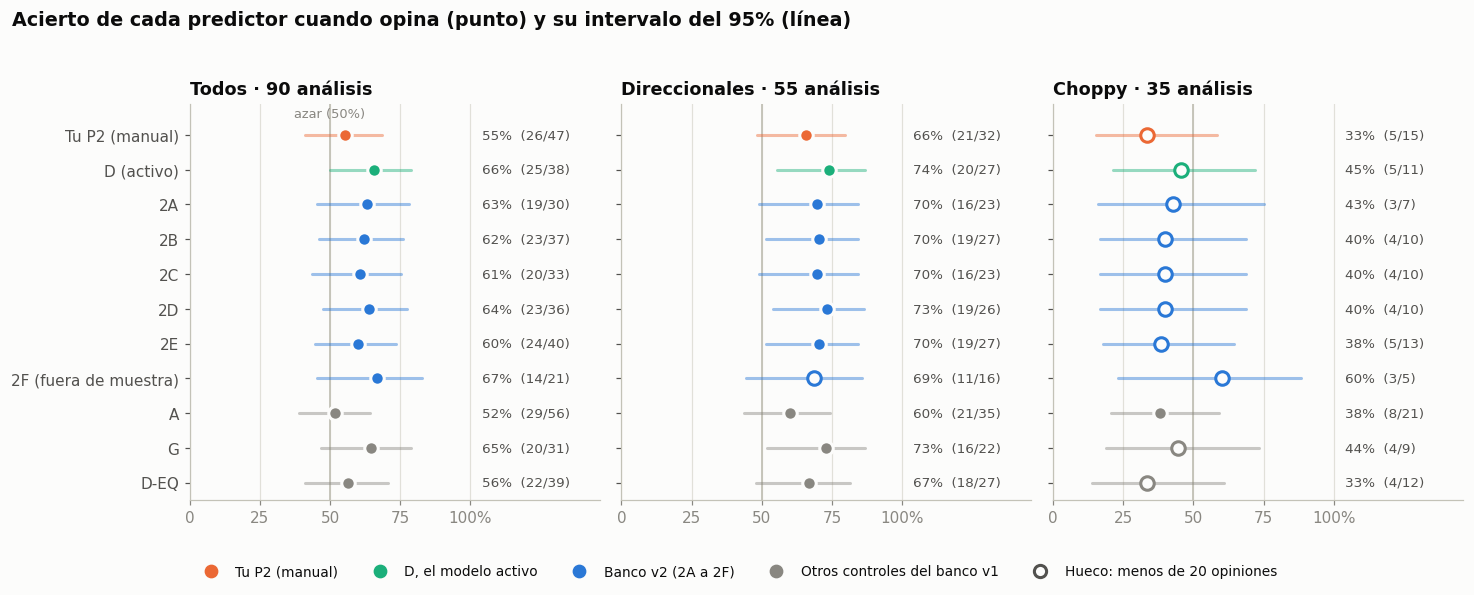

In [18]:
GRUPO = {DISC: ORANGE, "D": AQUA}
ORDEN = [DISC, "D"] + X_ALL + ["A", "G", "D-EQ"]
ETIQ = {DISC: "Tu P2 (manual)", "D": "D (activo)", "2F": "2F (fuera de muestra)"}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.2), sharey=True)
for ax, seg in zip(axes, SEG):
    for i, nombre in enumerate(ORDEN):
        st = stats(nombre, seg)
        color = GRUPO.get(nombre, BLUE if nombre in X_ALL else MUTED)
        if st.bets == 0:
            ax.text(50, i, "no opina", va="center", ha="center", fontsize=8.5, color=MUTED)
            continue
        lo, hi = st.ci
        ax.plot([lo * 100, hi * 100], [i, i], color=color, lw=2, alpha=0.45, solid_capstyle="round")
        ax.scatter(st.accuracy * 100, i, s=78, zorder=3, linewidth=2,
                   facecolor=SURF if st.insufficient else color, edgecolor=color if st.insufficient else SURF)
        ax.text(104, i, f"{st.accuracy * 100:.0f}%  ({st.hits}/{st.bets})", va="center", fontsize=8.8, color=INK2)
    ax.axvline(50, color=AXIS, lw=1.2, zorder=1)
    ax.set_xlim(0, 146)
    ax.set_xticks([0, 25, 50, 75, 100])
    ax.set_xticklabels(["0", "25", "50", "75", "100%"])
    ax.set_title(f"{seg} · {int(SEG[seg].sum())} análisis")
    ax.grid(axis="y", visible=False)
axes[0].set_yticks(range(len(ORDEN)), [ETIQ.get(n, n) for n in ORDEN])
axes[0].set_ylim(len(ORDEN) - 0.5, -0.9)
axes[0].text(50, -0.62, "azar (50%)", color=MUTED, fontsize=8.5, ha="center", va="center")
fig.legend(handles=[
    Line2D([], [], ls="", marker="o", ms=8, color=ORANGE, label="Tu P2 (manual)"),
    Line2D([], [], ls="", marker="o", ms=8, color=AQUA, label="D, el modelo activo"),
    Line2D([], [], ls="", marker="o", ms=8, color=BLUE, label="Banco v2 (2A a 2F)"),
    Line2D([], [], ls="", marker="o", ms=8, color=MUTED, label="Otros controles del banco v1"),
    Line2D([], [], ls="", marker="o", ms=8, markerfacecolor=SURF, markeredgecolor=INK2, markeredgewidth=2,
           label="Hueco: menos de 20 opiniones"),
], loc="lower center", ncol=5, fontsize=9, bbox_to_anchor=(0.5, -0.035))
fig.suptitle("Acierto de cada predictor cuando opina (punto) y su intervalo del 95% (línea)", x=0.012, ha="left",
             fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0.05, 1, 0.95))
mostrar(fig, "Tres paneles: Todos, Direccionales y Choppy. Para cada predictor, un punto con su acierto y una línea con su "
             "intervalo del 95%. Los valores están en la tabla de arriba.")

In [19]:
mejor_acc = max(X_FIXED, key=lambda x: stats(x).accuracy or 0)
rango_x = sorted(stats(x).accuracy for x in X_FIXED)
dir_x = sorted(stats(x, "Direccionales").accuracy for x in X_FIXED)
chop = {n: stats(n, "Choppy") for n in X_FIXED + ["D", DISC]}
sobre50_chop = [n for n, st in chop.items() if st.bets and st.accuracy >= 0.5]
sig_todos = [n for n in [DISC, "D"] + X_FIXED if stats(n).bets and stats(n).p_binom < v2.ALPHA]
sig_dir = [n for n in [DISC, "D"] + X_FIXED if stats(n, "Direccionales").bets >= v2.MIN_N
           and stats(n, "Direccionales").p_binom < v2.ALPHA]
md("### Resumen ejecutivo\n"
   f"- **Los cinco 2X quedan entre {pct(rango_x[0])} y {pct(rango_x[-1])}** cuando opinan. D, {pct(stats('D').accuracy)}. "
   f"Tu P2, {pct(stats(DISC).accuracy)}. Los intervalos se superponen casi por completo: **no hay un orden claro entre ellos**.\n"
   + (f"- **Ninguno se separa de una moneda** en el conjunto de todos los análisis (ningún p por debajo de 0.05).\n"
      if not sig_todos else f"- En todos los análisis, se separan de una moneda: {lista(sig_todos)}.\n")
   + f"- **En los análisis Direccionales todos mejoran:** los 2X entre {pct(dir_x[0])} y {pct(dir_x[-1])}, D "
     f"{pct(stats('D', 'Direccionales').accuracy)} y tu P2 {pct(stats(DISC, 'Direccionales').accuracy)}. "
   + (f"Con p por debajo de 0.05 quedan {lista(sig_dir)}, pero ojo: mirar un segmento aparte es exploratorio y ese p no "
      f"está corregido por haber mirado tres segmentos.\n" if sig_dir else "Ninguno llega a p < 0.05.\n")
   + (f"- **En Choppy, tu P2, D y los cinco 2X de pesos fijos quedan por debajo del 50%**, con menos de 20 opiniones cada "
      f"uno: no se concluye nada, salvo que ahí P2 no muestra ayudar. Que tu edge no apueste en Choppy sigue siendo lo "
      f"razonable.\n"
      if not sobre50_chop else f"- En Choppy llegan al 50% o más: {lista(sobre50_chop)} (con muy pocos casos).\n")
   + f"- **Lo que cambia entre modelos es cuánto opinan, más que cuánto aciertan:** D opina en {pct(stats('D').opina)} de los "
     f"análisis, {BEST} en {pct(stats(BEST).opina)} y A en {pct(stats('A').opina)}.")

### Resumen ejecutivo
- **Los cinco 2X quedan entre 60% y 64%** cuando opinan. D, 66%. Tu P2, 55%. Los intervalos se superponen casi por completo: **no hay un orden claro entre ellos**.
- **Ninguno se separa de una moneda** en el conjunto de todos los análisis (ningún p por debajo de 0.05).
- **En los análisis Direccionales todos mejoran:** los 2X entre 70% y 73%, D 74% y tu P2 66%. Con p por debajo de 0.05 quedan D y 2D, pero ojo: mirar un segmento aparte es exploratorio y ese p no está corregido por haber mirado tres segmentos.
- **En Choppy, tu P2, D y los cinco 2X de pesos fijos quedan por debajo del 50%**, con menos de 20 opiniones cada uno: no se concluye nada, salvo que ahí P2 no muestra ayudar. Que tu edge no apueste en Choppy sigue siendo lo razonable.
- **Lo que cambia entre modelos es cuánto opinan, más que cuánto aciertan:** D opina en 42% de los análisis, 2D en 40% y A en 62%.

## 5. Comparaciones pareadas

Comparar porcentajes sueltos engaña, porque cada predictor opina en análisis distintos. Acá cada comparación usa solo
los análisis donde **los dos opinan** (los "pares") y cuenta en cuántos acertó uno y falló el otro.

La regla para decir que un 2X **supera** a D se fijó de antemano y pide tres cosas a la vez:
1. que acierte más que D en los pares;
2. que esa ventaja sea difícil de explicar por suerte (McNemar exacto, p < 0.05);
3. que el 2X sobreviva a la corrección por haber probado 13 variantes (p < 0.05, §7).

Si falta cualquiera, queda "no distinguible" (o "inferior", si pierde con p < 0.05). Con menos de 20 pares, "no
concluyente". Con empate se mantiene D.

In [20]:
def tabla_pares(otro, labs, con_ic=False):
    filas = []
    for x in X_ALL:
        fila = {"Modelo": "2F (fuera de muestra)" if x == "2F" else x}
        for seg in SEG:
            pr = pair(x, otro, seg)
            txt = f"{pr.n} pares · {pr.b} a {pr.c}"
            if seg == "Todos":
                fila["Pares"] = pr.n
                fila["Opinan distinto"] = pr.n_disc
                fila[f"Acertó solo el 2X / solo {'tu P2' if otro == DISC else otro}"] = f"{pr.b} / {pr.c}"
                fila["Neto en los pares"] = f"{firmado(pr.net_x)} contra {firmado(pr.net_y)}"
                if con_ic:
                    fila["Diferencia de acierto (IC95)"] = (f"{pr.d * 100:+.0f} pts [{pr.ci[0] * 100:+.0f} a {pr.ci[1] * 100:+.0f}]"
                                                           if pr.n else "—")
                fila["McNemar p"] = pv(pr.p)
                fila["p por las 13 variantes"] = pv(p81(x, seg))
                fila["Dictamen"] = labs[seg][x]
            else:
                fila[f"{seg}"] = f"{txt} · {labs[seg][x]}"
        filas.append(fila)
    return pd.DataFrame(filas).set_index("Modelo")


md("### 5.1 Cada 2X contra D")
display(tabla_pares("D", LAB_D))
md("Para 2F, el \"p por las 13 variantes\" es el p de su propio procedimiento fuera de muestra (§6), porque 2F no "
   "forma parte de las 13. Las columnas Direccionales y Choppy muestran pares, aciertos de un lado y del otro, y el "
   "dictamen dentro de ese segmento.")

md("### 5.2 Si nunca opinan distinto, ¿en qué se diferencian?")
filas = []
for x in X_ALL:
    m = base(x)
    a, d = PRED[x], PRED["D"]
    ambos = m & (a != 0) & (d != 0)
    solo_x, solo_d = m & (a != 0) & (d == 0), m & (a == 0) & (d != 0)
    filas.append({"Modelo": "2F (fuera de muestra)" if x == "2F" else x,
                  "Opinan los dos": int(ambos.sum()), "…y coinciden en la dirección": int((ambos & (a == d)).sum()),
                  "Opina solo el 2X": frac(v2.predictor_stats(a, truth, solo_x)),
                  "Opina solo D": frac(v2.predictor_stats(d, truth, solo_d)),
                  "No opina ninguno": int((m & (a == 0) & (d == 0)).sum())})
display(pd.DataFrame(filas).set_index("Modelo"))
md("Esta tabla es descriptiva: no entra en la regla. Muestra dónde está la única diferencia real entre un 2X y D: en "
   "los análisis donde opina uno solo.")

### 5.1 Cada 2X contra D

,Pares,Opinan distinto,Acertó solo el 2X / solo D,Neto en los pares,McNemar p,p por las 13 variantes,Dictamen,Direccionales,Choppy
Modelo,,,,,,,,,
2A,26,0,0 / 0,+6 contra +6,1.000,0.320,no distinguible,19 pares · 0 a 0 · no concluyente,7 pares · 0 a 0 · no concluyente
2B,30,0,0 / 0,+10 contra +10,1.000,0.249,no distinguible,22 pares · 0 a 0 · no distinguible,8 pares · 0 a 0 · no concluyente
2C,26,0,0 / 0,+6 contra +6,1.000,0.367,no distinguible,19 pares · 0 a 0 · no concluyente,7 pares · 0 a 0 · no concluyente
2D,30,0,0 / 0,+10 contra +10,1.000,0.213,no distinguible,22 pares · 0 a 0 · no distinguible,8 pares · 0 a 0 · no concluyente
2E,30,0,0 / 0,+10 contra +10,1.000,0.320,no distinguible,22 pares · 0 a 0 · no distinguible,8 pares · 0 a 0 · no concluyente
2F (fuera de muestra),17,0,0 / 0,+5 contra +5,1.000,0.047,no concluyente,13 pares · 0 a 0 · no concluyente,4 pares · 0 a 0 · no concluyente


Para 2F, el "p por las 13 variantes" es el p de su propio procedimiento fuera de muestra (§6), porque 2F no forma parte de las 13. Las columnas Direccionales y Choppy muestran pares, aciertos de un lado y del otro, y el dictamen dentro de ese segmento.

### 5.2 Si nunca opinan distinto, ¿en qué se diferencian?

,Opinan los dos,…y coinciden en la dirección,Opina solo el 2X,Opina solo D,No opina ninguno
Modelo,,,,,
2A,26,26,3/4 = 75%,9/12 = 75%,48
2B,30,30,3/7 = 43%,5/8 = 62%,45
2C,26,26,4/7 = 57%,9/12 = 75%,45
2D,30,30,3/6 = 50%,5/8 = 62%,46
2E,30,30,4/10 = 40%,5/8 = 62%,42
2F (fuera de muestra),17,17,3/4 = 75%,4/4 = 100%,20


Esta tabla es descriptiva: no entra en la regla. Muestra dónde está la única diferencia real entre un 2X y D: en los análisis donde opina uno solo.

In [21]:
md("### 5.3 Cada 2X contra tu P2 manual")
display(tabla_pares(DISC, LAB_DISC, con_ic=True))
md("**«Equivalente»** quiere decir que el intervalo de la diferencia incluye el cero: la diferencia no se distingue "
   "del ruido de esta muestra. **No es una prueba de que sean iguales.** Con tan pocos pares donde opinan distinto, una "
   "diferencia real de 10 o 15 puntos cabría dentro de ese intervalo (§3).")

md("### 5.4 ¿Qué aporta cambiar solo las temporalidades? 2A contra D-EQ")
filas = []
for seg in SEG:
    pr = pair("2A", "D-EQ", seg)
    filas.append({"Segmento": seg, "Pares": pr.n, "Opinan distinto": pr.n_disc,
                  "Acertó solo 2A / solo D-EQ": f"{pr.b} / {pr.c}", "McNemar p": pv(pr.p),
                  "2A solo": celda(stats("2A", seg)), "D-EQ solo": celda(stats("D-EQ", seg)),
                  "Dictamen": v2.label_single_comparison(pr)})
display(pd.DataFrame(filas).set_index("Segmento"))
md("2A y D-EQ usan las mismas reglas y pesos iguales. Lo único que cambia es qué temporalidades miran: 1D, 2H, 1H, 30M y "
   "5M contra 1W, 1D, 12H, 4H, 1H y 30M. Por eso esta comparación aísla el efecto de las temporalidades.")

### 5.3 Cada 2X contra tu P2 manual

,Pares,Opinan distinto,Acertó solo el 2X / solo tu P2,Neto en los pares,Diferencia de acierto (IC95),McNemar p,p por las 13 variantes,Dictamen,Direccionales,Choppy
Modelo,,,,,,,,,,
2A,24,4,3 / 1,+10 contra +6,+8 pts [-7 a +15],0.625,0.320,equivalente,19 pares · 1 a 1 · no concluyente,5 pares · 2 a 0 · no concluyente
2B,28,6,4 / 2,+12 contra +8,+7 pts [-9 a +17],0.688,0.249,equivalente,21 pares · 1 a 1 · equivalente,7 pares · 3 a 1 · no concluyente
2C,23,4,3 / 1,+9 contra +5,+9 pts [-7 a +16],0.625,0.367,equivalente,18 pares · 1 a 1 · no concluyente,5 pares · 2 a 0 · no concluyente
2D,28,6,4 / 2,+12 contra +8,+7 pts [-9 a +17],0.688,0.213,equivalente,21 pares · 1 a 1 · equivalente,7 pares · 3 a 1 · no concluyente
2E,27,6,4 / 2,+11 contra +7,+7 pts [-9 a +18],0.688,0.320,equivalente,20 pares · 1 a 1 · equivalente,7 pares · 3 a 1 · no concluyente
2F (fuera de muestra),16,3,2 / 1,+10 contra +8,+6 pts [-11 a +16],1.000,0.047,no concluyente,13 pares · 0 a 1 · no concluyente,3 pares · 2 a 0 · no concluyente


**«Equivalente»** quiere decir que el intervalo de la diferencia incluye el cero: la diferencia no se distingue del ruido de esta muestra. **No es una prueba de que sean iguales.** Con tan pocos pares donde opinan distinto, una diferencia real de 10 o 15 puntos cabría dentro de ese intervalo (§3).

### 5.4 ¿Qué aporta cambiar solo las temporalidades? 2A contra D-EQ

,Pares,Opinan distinto,Acertó solo 2A / solo D-EQ,McNemar p,2A solo,D-EQ solo,Dictamen
Segmento,,,,,,,
Todos,23,0,0 / 0,1.000,19/30 = 63% [46–78],22/39 = 56% [41–71],no distinguible
Direccionales,17,0,0 / 0,1.000,16/23 = 70% [49–84],18/27 = 67% [48–81],no concluyente
Choppy,6,0,0 / 0,1.000,3/7 = 43% [16–75] · muestra insuficiente,4/12 = 33% [14–61] · muestra insuficiente,no concluyente


2A y D-EQ usan las mismas reglas y pesos iguales. Lo único que cambia es qué temporalidades miran: 1D, 2H, 1H, 30M y 5M contra 1W, 1D, 12H, 4H, 1H y 30M. Por eso esta comparación aísla el efecto de las temporalidades.

In [22]:
pd_best = pair(BEST, "D")
pdisc = [pair(x, DISC) for x in X_FIXED]
pr2f_d, pr2f_disc = pair("2F", "D"), pair("2F", DISC)
solo_x = v2.predictor_stats(PRED[BEST], truth, (PRED[BEST] != 0) & (PRED["D"] == 0))
solo_d = v2.predictor_stats(PRED["D"], truth, (PRED[BEST] == 0) & (PRED["D"] != 0))
md("### Resumen ejecutivo\n"
   + (f"- **Ningún 2X supera a D.** Los cinco de pesos fijos quedan «{LAB_D['Todos'][BEST]}»"
      if not SUPERAN else f"- **Superan a D:** {lista(SUPERAN)}.")
   + (f" y 2F «{LAB_D['Todos']['2F']}» ({pr2f_d.n} pares).\n" if not SUPERAN else "\n")
   + (f"- **La razón es de fondo, no de tamaño de muestra:** en los {RANGO_PARES} análisis donde cada 2X y D opinan los dos, "
      f"apuntan siempre para el mismo lado. No hay un solo análisis donde uno diga \"sube\" y el otro \"baja\". Son la "
      f"misma señal de tendencia, leída con otras velas.\n" if total_disc == 0 else
      f"- En los {RANGO_PARES} análisis donde cada 2X y D opinan los dos, opinan distinto {total_disc} veces (sumando los "
      f"cinco modelos).\n")
   + f"- **La diferencia está en cuándo opinan.** {BEST} opina solo (D calla) en {solo_x.bets} análisis y acierta "
     f"{solo_x.hits}. D opina solo en {solo_d.bets} y acierta {solo_d.hits}. Son muy pocos casos para sacar algo.\n"
   + f"- **Contra tu P2:** los 2X de pesos fijos quedan «{LAB_DISC['Todos'][BEST]}». Opinan distinto que vos en entre "
     f"{min(p.n_disc for p in pdisc)} y {max(p.n_disc for p in pdisc)} análisis, y en esos el modelo acierta "
     f"{pdisc[X_FIXED.index(BEST)].b} y vos {pdisc[X_FIXED.index(BEST)].c} (con {BEST}). No alcanza para decir que alguno "
     f"sea mejor. 2F: «{LAB_DISC['Todos']['2F']}» ({pr2f_disc.n} pares).\n"
   + f"- **Cambiar solo las temporalidades** (2A contra D-EQ): «{LAB_Q4}». "
   + (f"Tampoco opinan distinto nunca ({PAIR_Q4.n} pares).\n" if PAIR_Q4.n_disc == 0 else
      f"Opinan distinto en {PAIR_Q4.n_disc} de {PAIR_Q4.n} pares.\n")
   + {"no concluyente": f"- **Direccionales contra Choppy:** no se puede saber. En Choppy ninguna comparación llega a "
                        f"{v2.MIN_N} pares (tienen entre {min(pares_choppy)} y {max(pares_choppy)}).",
      "sí": "- **Direccionales contra Choppy:** cambia la etiqueta de "
            + lista([f"{x} contra {o}" for x, o in Q3_CHANGES]) + ".",
      "no": "- **Direccionales contra Choppy:** las etiquetas son las mismas en los dos segmentos."}[Q3])

### Resumen ejecutivo
- **Ningún 2X supera a D.** Los cinco de pesos fijos quedan «no distinguible» y 2F «no concluyente» (17 pares).
- **La razón es de fondo, no de tamaño de muestra:** en los 26 a 30 análisis donde cada 2X y D opinan los dos, apuntan siempre para el mismo lado. No hay un solo análisis donde uno diga "sube" y el otro "baja". Son la misma señal de tendencia, leída con otras velas.
- **La diferencia está en cuándo opinan.** 2D opina solo (D calla) en 6 análisis y acierta 3. D opina solo en 8 y acierta 5. Son muy pocos casos para sacar algo.
- **Contra tu P2:** los 2X de pesos fijos quedan «equivalente». Opinan distinto que vos en entre 4 y 6 análisis, y en esos el modelo acierta 4 y vos 2 (con 2D). No alcanza para decir que alguno sea mejor. 2F: «no concluyente» (16 pares).
- **Cambiar solo las temporalidades** (2A contra D-EQ): «no distinguible». Tampoco opinan distinto nunca (23 pares).
- **Direccionales contra Choppy:** no se puede saber. En Choppy ninguna comparación llega a 20 pares (tienen entre 3 y 8).

## 6. 2F: ¿y si los pesos los elige un procedimiento?

2A a 2E tienen pesos fijados a mano antes de mirar nada. 2F responde otra pregunta: **si dejamos que los datos elijan
los pesos, ¿sale algo mejor?** El riesgo es evidente: probando 10 626 combinaciones, alguna va a salir bien por pura
suerte. Por eso el resultado de 2F **nunca** es el de la mejor combinación sobre todos los análisis, sino este:

1. Se ordenan los análisis por fecha.
2. Con la primera mitad se elige la combinación de mayor neto. Si hay empate, gana la más parecida a 2A (pesos iguales).
3. Esa combinación predice los 10 análisis siguientes, que no participaron de la elección.
4. Se suman esos 10 a los conocidos, se vuelve a elegir, y se predice el bloque siguiente. Así hasta el final.

Lo que se reporta es el acierto sobre esos análisis "de prueba". A eso se le llama **fuera de muestra**.

In [23]:
md("### 6.1 Pesos elegidos")
fechas = [r.scoped.anchor for _, r in RES]
filas = []
for k, f in enumerate(TWOF.folds, 1):
    a1 = f["train"][1]
    t0, t1 = f["test"]
    st = v2.predictor_stats(TWOF.wf_pred, truth, (np.arange(N) >= t0) & (np.arange(N) < t1))
    fila = {"Tramo": f"{k}. Elige con los primeros {a1} y predice del {t0 + 1} al {t1}",
            "Análisis de prueba": f"{fechas[t0]:%d-%b} a {fechas[t1 - 1]:%d-%b}"}
    for tf, w in zip(v2.TIMEFRAMES_2X, f["weights"]):
        fila[tf] = f"{w:.2f}"
    fila["Aciertos en la prueba"] = frac(st) if st.bets else "no opinó"
    filas.append(fila)
fila = {"Tramo": f"Pesos finales (elegidos con los {N})", "Análisis de prueba": "—"}
for tf, w in zip(v2.TIMEFRAMES_2X, TWOF.final_weights):
    fila[tf] = f"{w:.2f}"
fila["Aciertos en la prueba"] = "no aplica: es dentro de muestra"
filas.append(fila)
display(pd.DataFrame(filas).set_index("Tramo"))
W = np.array([f["weights"] for f in TWOF.folds])
rangos = " · ".join(f"{tf} {W[:, j].min():.2f}–{W[:, j].max():.2f}" for j, tf in enumerate(v2.TIMEFRAMES_2X))
duplicado = [n for n, w in v2.WEIGHTS_2X.items() if np.allclose(w, TWOF.final_weights)]
md(f"**Rango de cada peso entre tramos:** {rangos}.\n\n"
   + (f"Los pesos finales coinciden con los de {duplicado[0]}: son el mismo modelo.\n\n" if duplicado else "")
   + "Los pesos finales quedan **congelados**: son los que se usarían para evaluar análisis nuevos, sin volver a elegir.")

### 6.1 Pesos elegidos

,Análisis de prueba,1D,2H,1H,30M,5M,Aciertos en la prueba
Tramo,,,,,,,
1. Elige con los primeros 45 y predice del 46 al 55,27-Jul a 07-Aug,0.15,0.60,0.00,0.20,0.05,3/3 = 100%
2. Elige con los primeros 55 y predice del 56 al 65,09-Aug a 18-Aug,0.05,0.50,0.20,0.00,0.25,4/6 = 67%
3. Elige con los primeros 65 y predice del 66 al 75,18-Aug a 24-Aug,0.05,0.50,0.20,0.00,0.25,5/7 = 71%
4. Elige con los primeros 75 y predice del 76 al 85,25-Aug a 31-Aug,0.05,0.50,0.20,0.00,0.25,0/2 = 0%
5. Elige con los primeros 85 y predice del 86 al 90,01-Sep a 16-Sep,0.00,0.50,0.00,0.25,0.25,2/3 = 67%
Pesos finales (elegidos con los 90),—,0.00,0.50,0.00,0.25,0.25,no aplica: es dentro de muestra


**Rango de cada peso entre tramos:** 1D 0.00–0.15 · 2H 0.50–0.60 · 1H 0.00–0.20 · 30M 0.00–0.25 · 5M 0.05–0.25.

Los pesos finales quedan **congelados**: son los que se usarían para evaluar análisis nuevos, sin volver a elegir.

In [24]:
md("### 6.2 Resultado fuera de muestra")
wf_st, loo_st = stats("2F"), v2.predictor_stats(TWOF.loo_pred, truth)
known_st = v2.predictor_stats(KNOWN.pred, truth, KNOWN.mask)
is_st = v2.predictor_stats(PG[:, TWOF.final_idx].astype(int), truth)
se = math.sqrt(PERM_2F_FINE[1] * (1 - PERM_2F_FINE[1]) / N_PERM_FINE)
display(pd.DataFrame([
    {"Medición": "Walk-forward (la principal): cada tramo predicho con pesos elegidos antes",
     "Aciertos": celda(wf_st), "Neto": firmado(wf_st.net), "Sobre": f"{wf_st.total} análisis de prueba",
     "p del procedimiento": f"{pv(PERM_2F['Todos'][1])} ({miles(N_PERM)} mezclas)"},
    {"Medición": "Control: el mismo walk-forward, usando solo resultados ya conocidos en cada ancla",
     "Aciertos": celda(known_st), "Neto": firmado(known_st.net), "Sobre": f"{known_st.total} análisis de prueba",
     "p del procedimiento": f"{pv(KNOWN.p)} ({miles(N_PERM)} mezclas)"},
    {"Medición": "Dejando uno afuera (secundaria): cada análisis predicho con pesos elegidos sin él",
     "Aciertos": celda(loo_st), "Neto": firmado(loo_st.net), "Sobre": f"{loo_st.total} análisis",
     "p del procedimiento": "—"},
    {"Medición": "Dentro de muestra (NO es el resultado de 2F): la mejor de las 10 626 sobre todos los análisis",
     "Aciertos": celda(is_st), "Neto": firmado(is_st.net), "Sobre": f"{is_st.total} análisis",
     "p del procedimiento": "—"},
]).set_index("Medición"))
md(f"**El p del procedimiento** responde: si la dirección del precio no tuviera nada que ver con las velas, ¿qué tan "
   f"seguido este mismo procedimiento (elegir, predecir, volver a elegir) sacaría un neto de {firmado(PERM_2F['Todos'][0])} "
   f"o más? Se mezclan los resultados al azar y se repite todo el procedimiento. Con las {miles(N_PERM)} mezclas fijadas de "
   f"antemano da **{pv(PERM_2F['Todos'][1])}**. Como control de precisión, con {miles(N_PERM_FINE)} mezclas da {PERM_2F_FINE[1]:.4f} "
   f"(error de simulación ±{1.96 * se:.4f}).")
mismo = (KNOWN.p < v2.ALPHA) == (PERM_2F["Todos"][1] < v2.ALPHA)
md(f"**Control de una fuga de información.** El walk-forward elige los pesos con los análisis anteriores por fecha. Pero el "
   f"resultado de un análisis se conoce recién cuando el precio toca un nivel, y eso puede pasar después de que empezó el "
   f"análisis que se quiere predecir. En **{KNOWN.tests_with_unknown} de los {int(KNOWN.mask.sum())}** análisis de prueba se "
   f"usó algún resultado que todavía no se conocía ({KNOWN.unknown_uses} usos en total). Es el mismo procedimiento del "
   f"cuaderno del banco v1, y es lo que fijó el pre-registro. Repitiéndolo solo con resultados ya conocidos da "
   f"{frac(known_st)}, neto {firmado(known_st.net)}, p = {pv(KNOWN.p)}: "
   + ("la conclusión es la misma." if mismo else "**cambia de lado del 0.05**, así que esa prueba no es firme."))

### 6.2 Resultado fuera de muestra

,Aciertos,Neto,Sobre,p del procedimiento
Medición,,,,
Walk-forward (la principal): cada tramo predicho con pesos elegidos antes,14/21 = 67% [45–83],+7,45 análisis de prueba,0.047 (10 000 mezclas)
"Control: el mismo walk-forward, usando solo resultados ya conocidos en cada ancla",13/19 = 68% [46–85] · muestra insuficiente,+7,45 análisis de prueba,0.047 (10 000 mezclas)
Dejando uno afuera (secundaria): cada análisis predicho con pesos elegidos sin él,24/45 = 53% [39–67],+3,90 análisis,—
Dentro de muestra (NO es el resultado de 2F): la mejor de las 10 626 sobre todos los análisis,34/54 = 63% [50–75],+14,90 análisis,—


**El p del procedimiento** responde: si la dirección del precio no tuviera nada que ver con las velas, ¿qué tan seguido este mismo procedimiento (elegir, predecir, volver a elegir) sacaría un neto de +7 o más? Se mezclan los resultados al azar y se repite todo el procedimiento. Con las 10 000 mezclas fijadas de antemano da **0.047**. Como control de precisión, con 100 000 mezclas da 0.0472 (error de simulación ±0.0013).

**Control de una fuga de información.** El walk-forward elige los pesos con los análisis anteriores por fecha. Pero el resultado de un análisis se conoce recién cuando el precio toca un nivel, y eso puede pasar después de que empezó el análisis que se quiere predecir. En **9 de los 45** análisis de prueba se usó algún resultado que todavía no se conocía (18 usos en total). Es el mismo procedimiento del cuaderno del banco v1, y es lo que fijó el pre-registro. Repitiéndolo solo con resultados ya conocidos da 13/19 = 68%, neto +7, p = 0.047: la conclusión es la misma.

### 6.3 Las 10 626 combinaciones, y dónde caen 2A a 2E

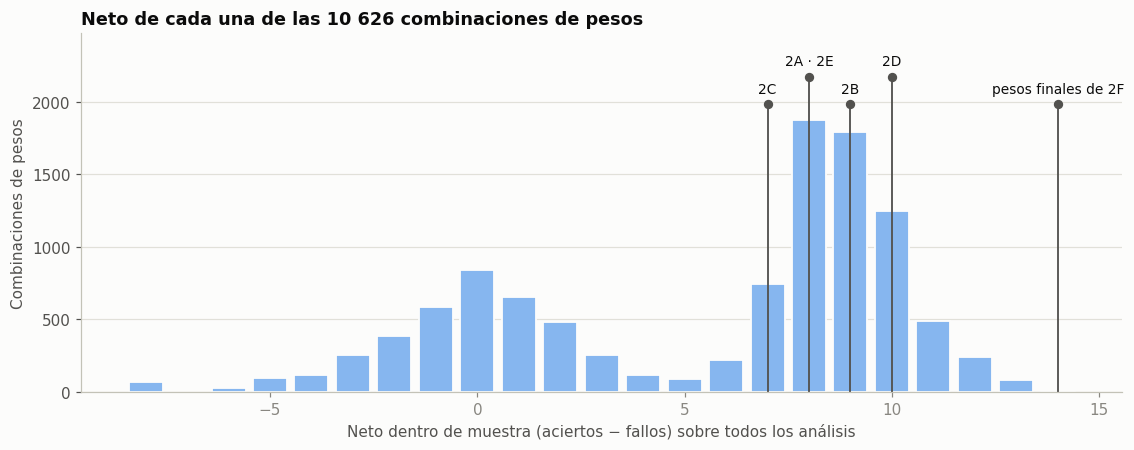

,Pesos (1D · 2H · 1H · 30M · 5M),Neto dentro de muestra,Percentil entre las 10 626
Modelo,,,
2A,0.20 · 0.20 · 0.20 · 0.20 · 0.20,+8,55
2B,0.10 · 0.25 · 0.25 · 0.20 · 0.20,+9,72
2C,0.20 · 0.20 · 0.20 · 0.30 · 0.10,+7,43
2D,0.15 · 0.30 · 0.25 · 0.20 · 0.10,+10,87
2E,0.10 · 0.25 · 0.30 · 0.25 · 0.10,+8,55


El neto de las 10 626 combinaciones va de -8 a +14, con mediana +8. **Percentil 50** sería estar justo en el medio; cerca de 100, entre las mejores.

**¿Qué separa a los dos grupos del gráfico?** El peso de cada temporalidad:

,Sola (todo el peso en ella),Neto sola,Neto medio con peso de 0.25 o más,Neto medio con peso de 0.20 o menos
Temporalidad,,,,
1D,1/10 = 10% [2–40] · muestra insuficiente,-8,-0.2,+8.8
2H,22/34 = 65% [48–79],+10,+7.2,+4.6
1H,20/31 = 65% [47–79],+9,+6.6,+4.9
30M,18/28 = 64% [46–79],+8,+6.8,+4.8
5M,16/24 = 67% [47–82],+8,+6.7,+4.9


Una temporalidad con peso de 0.25 o más puede decidir la predicción por sí sola; con menos, necesita que otra la acompañe. 3876 combinaciones le dan 0.25 o más a 1D y promedian neto -0.2; las otras 6750 promedian +8.8. 2A a 2E tienen 1D entre 0.10 y 0.20. Esto describe lo que pasó en estos 90 análisis; no prueba que 1D "no sirva".

In [25]:
md("### 6.3 Las 10 626 combinaciones, y dónde caen 2A a 2E")
nets = TWOF.in_sample_net
valores, cuentas = np.unique(nets, return_counts=True)
fig, ax = plt.subplots(figsize=(10.5, 4.2))
ax.bar(valores, cuentas, width=0.82, color=BLUE_SOFT, edgecolor=SURF, linewidth=1.2)
ax.grid(axis="x", visible=False)
por_neto = {}
for nombre, w in v2.WEIGHTS_2X.items():
    por_neto.setdefault(int(nets[v2.grid_index(GRID, w)]), []).append(nombre)
por_neto.setdefault(int(nets[TWOF.final_idx]), []).append("pesos finales de 2F")
tope = cuentas.max()
for k, (neto, nombres) in enumerate(sorted(por_neto.items())):
    alto = tope * (1.06 + 0.10 * (k % 2))
    ax.plot([neto, neto], [0, alto], color=INK2, lw=1.2)
    ax.scatter([neto], [alto], s=26, color=INK2, zorder=3)
    ax.text(neto, alto + tope * 0.03, " · ".join(nombres), ha="center", va="bottom", fontsize=9, color=INK)
ax.set_ylim(0, tope * 1.32)
ax.set_xlabel("Neto dentro de muestra (aciertos − fallos) sobre todos los análisis")
ax.set_ylabel("Combinaciones de pesos")
ax.set_title("Neto de cada una de las 10 626 combinaciones de pesos")
plt.tight_layout()
mostrar(fig, "Histograma del neto dentro de muestra de las 10 626 combinaciones de pesos, con marcas donde caen 2A a 2E y los pesos finales de 2F. Los valores están en la tabla de abajo.")

filas = []
for nombre, w in v2.WEIGHTS_2X.items():
    x = int(nets[v2.grid_index(GRID, w)])
    filas.append({"Modelo": nombre, "Pesos (1D · 2H · 1H · 30M · 5M)": " · ".join(f"{v:.2f}" for v in w),
                  "Neto dentro de muestra": firmado(x), "Percentil entre las 10 626": f"{v2.mid_rank_percentile(nets, x):.0f}"})
display(pd.DataFrame(filas).set_index("Modelo"))
md(f"El neto de las 10 626 combinaciones va de {firmado(int(nets.min()))} a {firmado(int(nets.max()))}, con mediana "
   f"{firmado(int(np.median(nets)))}. **Percentil 50** sería estar justo en el medio; cerca de 100, entre las mejores.")

md("**¿Qué separa a los dos grupos del gráfico?** El peso de cada temporalidad:")
SOLA = {}
for j, tf in enumerate(v2.TIMEFRAMES_2X):
    w = [0.0] * len(v2.TIMEFRAMES_2X)
    w[j] = 1.0
    SOLA[tf] = v2.predictor_stats(PG[:, v2.grid_index(GRID, w)].astype(int), truth)
filas = []
for j, tf in enumerate(v2.TIMEFRAMES_2X):
    alto = GRID[:, j] >= 0.25 - 1e-9
    filas.append({"Temporalidad": tf, "Sola (todo el peso en ella)": celda(SOLA[tf]), "Neto sola": firmado(SOLA[tf].net),
                  "Neto medio con peso de 0.25 o más": f"{nets[alto].mean():+.1f}",
                  "Neto medio con peso de 0.20 o menos": f"{nets[~alto].mean():+.1f}"})
display(pd.DataFrame(filas).set_index("Temporalidad"))
PESO_1D_ALTO = GRID[:, 0] >= 0.25 - 1e-9
cortas = [SOLA[tf].net for tf in v2.TIMEFRAMES_2X[1:]]
md(f"Una temporalidad con peso de 0.25 o más puede decidir la predicción por sí sola; con menos, necesita que otra la "
   f"acompañe. {int(PESO_1D_ALTO.sum())} combinaciones le dan 0.25 o más a 1D y promedian neto "
   f"{nets[PESO_1D_ALTO].mean():+.1f}; las otras {int((~PESO_1D_ALTO).sum())} promedian {nets[~PESO_1D_ALTO].mean():+.1f}. "
   f"2A a 2E tienen 1D entre {min(w[0] for w in v2.WEIGHTS_2X.values()):.2f} y "
   f"{max(w[0] for w in v2.WEIGHTS_2X.values()):.2f}. Esto describe lo que pasó en estos {N} análisis; no prueba que 1D "
   f"\"no sirva\".")

In [26]:
pr = pair("2F", "D")
perc = {n: v2.mid_rank_percentile(nets, int(nets[v2.grid_index(GRID, w)])) for n, w in v2.WEIGHTS_2X.items()}
h2_w = W[:, list(v2.TIMEFRAMES_2X).index("2H")]
md("### Resumen ejecutivo\n"
   f"- **Fuera de muestra, 2F acierta {frac(wf_st)}** (neto {firmado(wf_st.net)}) en los {wf_st.total} análisis de prueba. "
   f"El p del procedimiento es {pv(PERM_2F['Todos'][1])}: "
   + ("por debajo de 0.05, pero pegado al límite. " if 0.03 < PERM_2F['Todos'][1] < v2.ALPHA else
      ("claramente por debajo de 0.05. " if PERM_2F['Todos'][1] < v2.ALPHA else "no alcanza para descartar la suerte. "))
   + f"La otra forma de medirlo, dejando un análisis afuera por vez, da {frac(loo_st)} (neto {firmado(loo_st.net)}): "
   + ("bastante peor. Las dos mediciones no cuentan la misma historia, y eso es señal de un resultado frágil.\n"
      if (wf_st.accuracy or 0) - (loo_st.accuracy or 0) > 0.08 else "parecido.\n")
   + f"- **El walk-forward usaba algunos resultados que todavía no se conocían** ({KNOWN.tests_with_unknown} de "
     f"{int(KNOWN.mask.sum())} análisis de prueba). Corregido, da neto {firmado(known_st.net)} y p = {pv(KNOWN.p)}: "
   + ("no cambia nada.\n" if mismo else "cambia de lado del 0.05.\n")
   + f"- **Contra D no se puede comparar:** {pr.n} pares, menos de {v2.MIN_N}"
   + (", y en ninguno opinan distinto.\n" if pr.n_disc == 0 else f", y opinan distinto en {pr.n_disc}.\n")
   + f"- **El procedimiento siempre carga el peso en 2H** (entre {h2_w.min():.2f} y {h2_w.max():.2f}). El resto de los pesos "
     f"cambia de un tramo a otro: no hay un reparto estable.\n"
   f"- **Lo que más mueve el resultado es cuánto pesa 1D.** Sola, 1D acierta {frac(SOLA['1D'])} (neto "
   f"{firmado(SOLA['1D'].net)}). Las combinaciones que le dan 0.25 o más promedian neto {nets[PESO_1D_ALTO].mean():+.1f}; "
   f"las demás, {nets[~PESO_1D_ALTO].mean():+.1f}. Cómo se reparte el resto entre 2H, 1H, 30M y 5M casi no importa: cada "
   f"una sola da entre {firmado(min(cortas))} y {firmado(max(cortas))}.\n"
   f"- **2A a 2E son repartos comunes:** caen entre los percentiles {min(perc.values()):.0f} y {max(perc.values()):.0f} de "
   f"las 10 626. El mejor reparto posible, mirando todos los datos, llega a neto {firmado(int(nets.max()))}.\n"
   f"- **Por qué ayudan las temporalidades cortas y no 1D es solo una hipótesis:** el precio tarda una mediana de "
   f"{np.median(horas):.0f} horas en tocar un nivel, que son pocas velas de 2H y menos de media vela diaria. Estos datos "
   f"no lo pueden probar.")

### Resumen ejecutivo
- **Fuera de muestra, 2F acierta 14/21 = 67%** (neto +7) en los 45 análisis de prueba. El p del procedimiento es 0.047: por debajo de 0.05, pero pegado al límite. La otra forma de medirlo, dejando un análisis afuera por vez, da 24/45 = 53% (neto +3): bastante peor. Las dos mediciones no cuentan la misma historia, y eso es señal de un resultado frágil.
- **El walk-forward usaba algunos resultados que todavía no se conocían** (9 de 45 análisis de prueba). Corregido, da neto +7 y p = 0.047: no cambia nada.
- **Contra D no se puede comparar:** 17 pares, menos de 20, y en ninguno opinan distinto.
- **El procedimiento siempre carga el peso en 2H** (entre 0.50 y 0.60). El resto de los pesos cambia de un tramo a otro: no hay un reparto estable.
- **Lo que más mueve el resultado es cuánto pesa 1D.** Sola, 1D acierta 1/10 = 10% (neto -8). Las combinaciones que le dan 0.25 o más promedian neto -0.2; las demás, +8.8. Cómo se reparte el resto entre 2H, 1H, 30M y 5M casi no importa: cada una sola da entre +8 y +10.
- **2A a 2E son repartos comunes:** caen entre los percentiles 43 y 87 de las 10 626. El mejor reparto posible, mirando todos los datos, llega a neto +14.
- **Por qué ayudan las temporalidades cortas y no 1D es solo una hipótesis:** el precio tarda una mediana de 11 horas en tocar un nivel, que son pocas velas de 2H y menos de media vela diaria. Estos datos no lo pueden probar.

## 7. ¿Es sobreajuste?

La sospecha de siempre: si se prueban muchas variantes y se mira la mejor, esa mejor puede ser solo suerte. Estas
pruebas repiten las de la sección 8 del cuaderno del banco v1, aplicadas al **mejor 2X de pesos fijos**. Los criterios
de ✅, ⚠️ y ❌ se fijaron con números antes de calcular.

### 7.1 Permutación con la selección incluida · el mejor 2X es **2D**

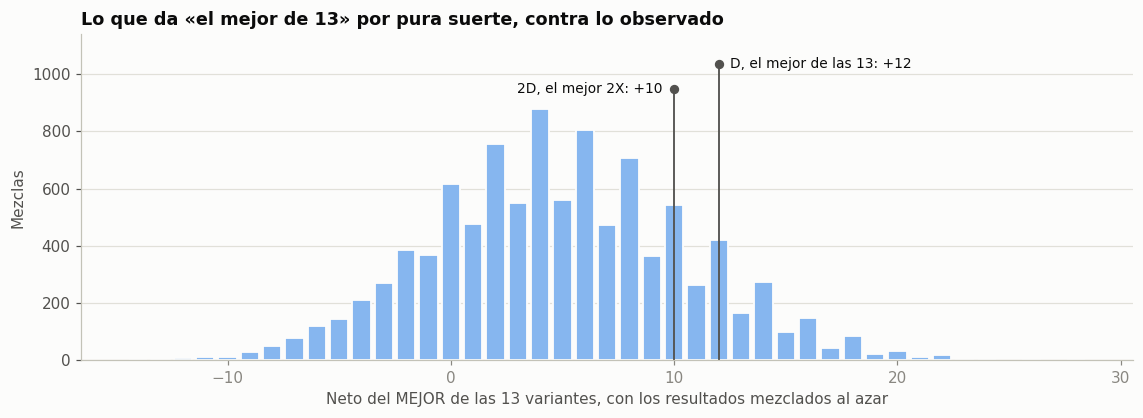

,Neto,p corregido (Todos),Neto en Direccionales,p corregido (Direccionales),Neto en Choppy,p corregido (Choppy)
Modelo,,,,,,
D,+12,0.132,+13,0.031,-1,0.944
E,+10,0.213,+12,0.039,-2,0.973
2D,+10,0.213,+12,0.039,-2,0.973
F,+9,0.249,+13,0.031,-4,0.996
G,+9,0.249,+10,0.086,-1,0.944
2B,+9,0.249,+11,0.071,-2,0.973
2A,+8,0.320,+9,0.148,-1,0.944
2E,+8,0.320,+11,0.071,-3,0.992
2C,+7,0.367,+9,0.148,-2,0.973


Se mezclan al azar los resultados reales 10 000 veces y en cada mezcla se toma **el mejor de los 13**. Por pura suerte, el mejor de 13 da en promedio +5, y una de cada veinte veces llega a +14 o más. El **p corregido** de cada modelo es la fracción de mezclas en las que el mejor de los 13 iguala o supera su neto.

**Por segmento (exploratorio).** Mirando solo los análisis Direccionales, quedan por debajo de 0.05 D, F, E y 2D. Es el único lugar donde aparece algo, pero hay que leerlo con cuidado: el segmento se mira aparte, y ese p corrige por las 13 variantes pero no por haber mirado tres segmentos. En Choppy todos los netos son negativos.

In [27]:
md(f"### 7.1 Permutación con la selección incluida · el mejor 2X es **{BEST}**")
obs_fam, obs_best = NETS["Todos"][BEST_FAMILY], NETS["Todos"][BEST]
nula = NULL["Todos"]
valores, cuentas = np.unique(nula, return_counts=True)
fig, ax = plt.subplots(figsize=(10.5, 3.9))
ax.bar(valores, cuentas, width=0.82, color=BLUE_SOFT, edgecolor=SURF, linewidth=1.2)
ax.grid(axis="x", visible=False)
tope = cuentas.max()
marcas = {}
marcas.setdefault(obs_best, []).append(f"{BEST}, el mejor 2X")
marcas.setdefault(obs_fam, []).append(f"{BEST_FAMILY}, el mejor de las 13")
ordenadas = sorted(marcas.items())
for k, (neto, nombres) in enumerate(ordenadas):
    alto = tope * (1.08 + 0.10 * k)
    ax.plot([neto, neto], [0, alto], color=INK2, lw=1.2)
    ax.scatter([neto], [alto], s=26, color=INK2, zorder=3)
    izquierda = len(ordenadas) > 1 and k == 0          # la de menor neto se rotula hacia la izquierda
    ax.text(neto + (-0.5 if izquierda else 0.5), alto, " · ".join(nombres) + f": {firmado(neto)}",
            ha="right" if izquierda else "left", va="center", fontsize=9, color=INK)
ax.set_ylim(0, tope * 1.30)
ax.set_xlabel("Neto del MEJOR de las 13 variantes, con los resultados mezclados al azar")
ax.set_ylabel("Mezclas")
ax.set_title("Lo que da «el mejor de 13» por pura suerte, contra lo observado")
plt.tight_layout()
mostrar(fig, "Histograma del neto del mejor de las 13 variantes con los resultados mezclados al azar, con marcas en el neto observado del mejor 2X y del mejor de las 13. Los valores están en la tabla de abajo.")
display(pd.DataFrame([{"Modelo": k, "Neto": firmado(NETS["Todos"][k]), "p corregido (Todos)": pv(P81["Todos"][k]),
                       "Neto en Direccionales": firmado(NETS["Direccionales"][k]),
                       "p corregido (Direccionales)": pv(P81["Direccionales"][k]),
                       "Neto en Choppy": firmado(NETS["Choppy"][k]), "p corregido (Choppy)": pv(P81["Choppy"][k])}
                      for k in sorted(MODELS, key=lambda k: -NETS["Todos"][k])]).set_index("Modelo"))
md(f"Se mezclan al azar los resultados reales {miles(N_PERM)} veces y en cada mezcla se toma **el mejor de los 13**. Por "
   f"pura suerte, el mejor de 13 da en promedio {firmado(int(round(nula.mean())))}, y una de cada veinte veces llega a "
   f"{firmado(int(np.quantile(nula, 0.95)))} o más. El **p corregido** de cada modelo es la fracción de mezclas en las que "
   f"el mejor de los 13 iguala o supera su neto.")
bajo_dir = [k for k in MODELS if P81["Direccionales"][k] < v2.ALPHA]
if bajo_dir:
    md(f"**Por segmento (exploratorio).** Mirando solo los análisis Direccionales, quedan por debajo de 0.05 "
       f"{lista(sorted(bajo_dir, key=lambda k: P81['Direccionales'][k]))}. Es el único lugar donde aparece algo, pero hay que "
       f"leerlo con cuidado: el segmento se mira aparte, y ese p corrige por las 13 variantes pero no por haber mirado "
       f"tres segmentos. En Choppy todos los netos son negativos.")

In [28]:
md("### 7.2 Estabilidad en el tiempo y por activo")
filas = []
for etiqueta, m in MITADES.items():
    idx = np.where(m)[0]
    fila = {"Tramo": f"{etiqueta} ({fechas[idx[0]]:%d-%b} a {fechas[idx[-1]]:%d-%b})", "Análisis": int(m.sum())}
    for nombre in (BEST, "D", DISC):
        st = stats(nombre, extra=m)
        fila["Tu P2" if nombre == DISC else nombre] = f"{st.hits}/{st.bets} · neto {firmado(st.net)}"
    filas.append(fila)
for activo in ACC:
    m = asset == activo
    fila = {"Tramo": activo, "Análisis": int(m.sum())}
    for nombre in (BEST, "D", DISC):
        st = stats(nombre, extra=m)
        fila["Tu P2" if nombre == DISC else nombre] = f"{st.hits}/{st.bets} · neto {firmado(st.net)}" + (" · insuficiente" if st.insufficient else "")
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Tramo"))
NETO_MITAD = [stats(BEST, extra=m).net for m in MITADES.values()]
NETO_ACTIVO = {a: stats(BEST, extra=asset == a).net for a in ACC}

md("### 7.3 Vecinos en la grilla: ¿el resultado depende de un reparto exacto?")
cuenta_vec = Counter(net for _, net in VECINOS)
display(pd.DataFrame([{"Neto del vecino": firmado(net), "Diferencia con " + BEST: firmado(net - BEST_NET_IS),
                       "Cuántos vecinos": k} for net, k in sorted(cuenta_vec.items(), reverse=True)]).set_index("Neto del vecino"))
md(f"Son los {len(VECINOS)} repartos que salen de mover 0.05 de una temporalidad a otra desde {BEST} "
   f"({' · '.join(f'{v:.2f}' for v in BEST_W)}, neto {firmado(BEST_NET_IS)}). **{pct(VECINOS_CERCA)}** quedan a 2 o menos del "
   f"neto de {BEST}.")

md("### 7.4 ¿Acierta solo porque el período fue para un lado?")
b = PRED[BEST]
md(f"- {BEST} dijo \"sube\" {int((b > 0).sum())} veces y acertó {int(((b > 0) & (truth > 0)).sum())}; dijo \"baja\" "
   f"{int((b < 0).sum())} veces y acertó {int(((b < 0) & (truth < 0)).sum())}.\n"
   f"- En esos mismos {int(opina_best.sum())} análisis, decir **siempre \"sube\"** habría acertado {K_LONG} y **siempre "
   f"\"baja\"** {K_SHORT}. {BEST} acertó {K_BEST}.")

### 7.2 Estabilidad en el tiempo y por activo

,Análisis,2D,D,Tu P2
Tramo,,,,
1ª mitad (18-May a 27-Jul),45,8/15 · neto +1,10/17 · neto +3,12/25 · neto -1
2ª mitad (27-Jul a 16-Sep),45,15/21 · neto +9,15/21 · neto +9,14/22 · neto +6
XAUUSD,68,19/30 · neto +8,21/33 · neto +9,20/37 · neto +3
BTCUSD,22,4/6 · neto +2 · insuficiente,4/5 · neto +3 · insuficiente,6/10 · neto +2 · insuficiente


### 7.3 Vecinos en la grilla: ¿el resultado depende de un reparto exacto?

,Diferencia con 2D,Cuántos vecinos
Neto del vecino,,
+10,+0,11
+9,-1,9


Son los 20 repartos que salen de mover 0.05 de una temporalidad a otra desde 2D (0.15 · 0.30 · 0.25 · 0.20 · 0.10, neto +10). **100%** quedan a 2 o menos del neto de 2D.

### 7.4 ¿Acierta solo porque el período fue para un lado?

- 2D dijo "sube" 20 veces y acertó 12; dijo "baja" 16 veces y acertó 11.
- En esos mismos 36 análisis, decir **siempre "sube"** habría acertado 17 y **siempre "baja"** 19. 2D acertó 23.

### 7.5 ¿El indicador funciona por sí solo? 2D y D en momentos al azar

,Aciertos,IC95,Opina en,p contra 50%,Tus momentos contra estos
Dónde se aplica,,,,,
2D en TUS momentos (XAUUSD),19/30 = 63%,[46–78],44%,0.200,—
"2D al azar, cualquier hora",91/176 = 52%,[44–59],44%,0.706,+12 pts · p = 0.238
"2D al azar, 5:00 a 8:59",76/151 = 50%,[42–58],43%,1.000,+13 pts · p = 0.193
D en TUS momentos (XAUUSD),21/33 = 64%,[47–78],49%,0.163,—
"D al azar, cualquier hora",77/161 = 48%,[40–56],40%,0.636,+16 pts · p = 0.098
"D al azar, 5:00 a 8:59",79/154 = 51%,[43–59],44%,0.809,+12 pts · p = 0.197


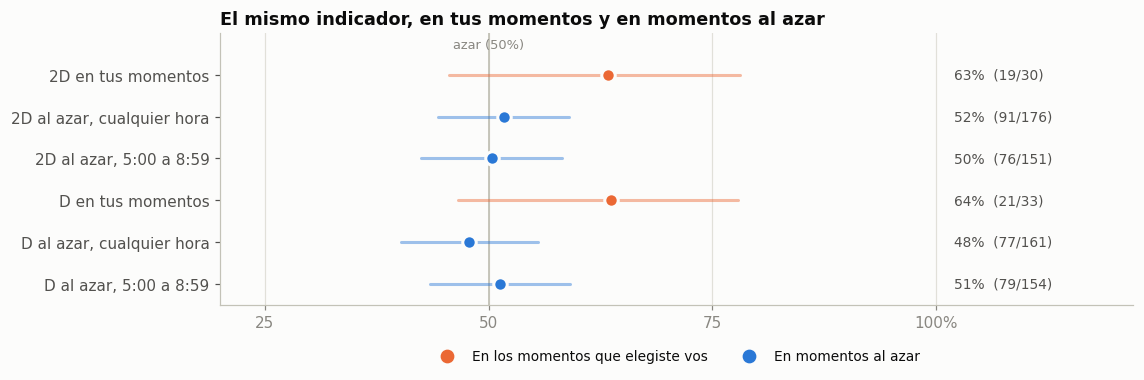

Hasta acá, los modelos se midieron solo en los momentos que **vos** elegiste para analizar y con **tus** niveles. Para saber si el indicador predice algo por sí mismo, se aplica en 400 momentos al azar de XAUUSD del mismo período, con niveles simétricos a ±40.8 puntos (la distancia típica de los tuyos), y se mide igual. Hay dos grupos: a cualquier hora, y solo entre las 5:00 y las 8:59 (hora de Guatemala), la franja donde hacés la mayoría de tus análisis. Momentos con resultado: 400 (cualquier hora), 350 (5:00 a 8:59).

In [29]:
md(f"### 7.5 ¿El indicador funciona por sí solo? {BEST} y D en momentos al azar")
filas, puntos = [], []
for modelo in (BEST, "D"):
    st = TUYOS[modelo]
    filas.append({"Dónde se aplica": f"{modelo} en TUS momentos (XAUUSD)", "Aciertos": frac(st), "IC95": ic(st),
                  "Opina en": pct(st.opina), "p contra 50%": pv(st.p_binom), "Tus momentos contra estos": "—"})
    puntos.append((f"{modelo} en tus momentos", st, ORANGE))
    for grupo in AZAR:
        a = azar_stats(grupo, modelo)
        p2 = v2.two_proportions_p(st.hits, st.bets, a.hits, a.bets)
        filas.append({"Dónde se aplica": f"{modelo} al azar, {grupo}", "Aciertos": frac(a), "IC95": ic(a),
                      "Opina en": pct(a.opina), "p contra 50%": pv(a.p_binom),
                      "Tus momentos contra estos": f"{(st.accuracy - a.accuracy) * 100:+.0f} pts · p = {pv(p2)}"})
        puntos.append((f"{modelo} al azar, {grupo}", a, BLUE))
display(pd.DataFrame(filas).set_index("Dónde se aplica"))

fig, ax = plt.subplots(figsize=(10.5, 3.6))
for i, (etq, st, color) in enumerate(puntos):
    lo, hi = st.ci
    ax.plot([lo * 100, hi * 100], [i, i], color=color, lw=2, alpha=0.45, solid_capstyle="round")
    ax.scatter(st.accuracy * 100, i, s=78, color=color, edgecolor=SURF, linewidth=2, zorder=3)
    ax.text(102, i, f"{st.accuracy * 100:.0f}%  ({st.hits}/{st.bets})", va="center", fontsize=9, color=INK2)
ax.axvline(50, color=AXIS, lw=1.2, zorder=1)
ax.text(50, -0.72, "azar (50%)", color=MUTED, fontsize=8.5, ha="center", va="center")
ax.set_yticks(range(len(puntos)), [e for e, *_ in puntos])
ax.set_xlim(20, 122); ax.set_ylim(len(puntos) - 0.5, -1.0)
ax.set_xticks([25, 50, 75, 100]); ax.set_xticklabels(["25", "50", "75", "100%"])
ax.grid(axis="y", visible=False)
ax.set_title("El mismo indicador, en tus momentos y en momentos al azar")
ax.legend(handles=[Line2D([], [], ls="", marker="o", ms=8, color=ORANGE, label="En los momentos que elegiste vos"),
                   Line2D([], [], ls="", marker="o", ms=8, color=BLUE, label="En momentos al azar")],
          loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
plt.tight_layout()
mostrar(fig, "Acierto e intervalo del 95% del mejor 2X y de D, en tus momentos y en momentos al azar. Los valores están en la tabla de arriba.")
res_az = {g: int((df["estado"] == v2.S1_RESOLVED).sum()) for g, df in AZAR.items()}
md(f"Hasta acá, los modelos se midieron solo en los momentos que **vos** elegiste para analizar y con **tus** niveles. "
   f"Para saber si el indicador predice algo por sí mismo, se aplica en 400 momentos al azar de XAUUSD del mismo período, "
   f"con niveles simétricos a ±{BANDA:.1f} puntos (la distancia típica de los tuyos), y se mide igual. Hay dos grupos: a "
   f"cualquier hora, y solo entre las 5:00 y las 8:59 (hora de Guatemala), la franja donde hacés la mayoría de tus "
   f"análisis. Momentos con resultado: {', '.join(f'{v} ({k})' for k, v in res_az.items())}.")

### 7.6 Geometría de los niveles y minuto del ancla

,Aciertos,IC95
Predictor,,
Siempre la dirección de tu tesis,48/90 = 53%,[43–63]
Siempre hacia el nivel más cercano,54/90 = 60%,[50–70]
"2D, todas sus opiniones",23/36 = 64%,[48–78]
2D cuando apunta al nivel más cercano,14/20 = 70%,[48–85]
2D cuando apunta al nivel más lejano,9/16 = 56%,[33–77]


**Geometría.** Si uno de tus dos niveles suele quedar más cerca, gana más seguido por pura distancia. Tu validación queda a 1.10× la distancia de tu invalidación (mediana). Por pura distancia la tesis se confirmaría 48% de las veces; se confirma 53%.

,Resueltos,2D,D,Tu P2
Ancla,,,,
created_at − 0 min,91,24/37 = 65% [49–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 5 min,90,23/36 = 64% [48–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 10 min,90,24/37 = 65% [49–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 15 min,90,23/36 = 64% [48–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 20 min ← la usada,90,23/36 = 64% [48–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 30 min,90,23/36 = 64% [48–78],25/38 = 66% [50–79],26/47 = 55% [41–69]
created_at − 60 min,87,25/38 = 66% [50–79],25/36 = 69% [53–82],26/45 = 58% [43–71]


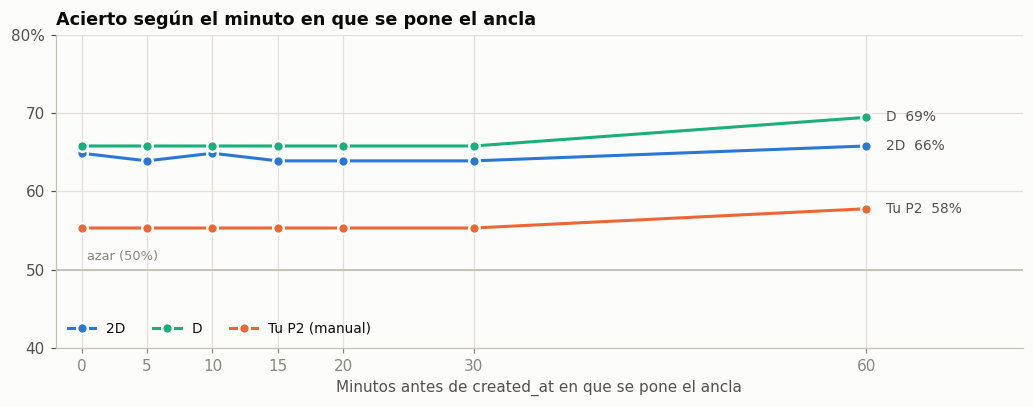

**Ancla.** La base de datos no guarda la hora en que decidiste P2. Moviendo el ancla entre 0 y 60 minutos, el acierto de 2D se mueve como máximo 2 puntos respecto del valor con 20 minutos.

In [30]:
md("### 7.6 Geometría de los niveles y minuto del ancla")
display(pd.DataFrame([{"Predictor": k, "Aciertos": frac(st), "IC95": ic(st)} for k, st in GEO.items()]).set_index("Predictor"))
md(f"**Geometría.** Si uno de tus dos niveles suele quedar más cerca, gana más seguido por pura distancia. Tu validación "
   f"queda a {np.median(dist_v / dist_i):.2f}× la distancia de tu invalidación (mediana). Por pura distancia la tesis se "
   f"confirmaría {pct(ESPERADO_DIST)} de las veces; se confirma {pct(CONFIRMADA)}.")

filas = []
for lead in LEADS:
    fila = {"Ancla": f"created_at − {lead} min" + ("  ← la usada" if lead == LEAD else ""), "Resueltos": SWEEP[lead]["resueltos"]}
    for nombre in (BEST, "D", DISC):
        fila["Tu P2" if nombre == DISC else nombre] = celda(SWEEP[lead][nombre])
    filas.append(fila)
display(pd.DataFrame(filas).set_index("Ancla"))

fig, ax = plt.subplots(figsize=(9.5, 3.8))
for nombre, color in ((BEST, BLUE), ("D", AQUA), (DISC, ORANGE)):
    ys = [SWEEP[l][nombre].accuracy * 100 for l in LEADS]
    ax.plot(LEADS, ys, color=color, marker="o", ms=7, markeredgecolor=SURF, markeredgewidth=1.6,
            label="Tu P2 (manual)" if nombre == DISC else nombre)
    ax.text(LEADS[-1] + 1.5, ys[-1], f"{'Tu P2' if nombre == DISC else nombre}  {ys[-1]:.0f}%", va="center", fontsize=9, color=INK2)
ax.axhline(50, color=AXIS, lw=1.2, zorder=1)
ax.text(0.4, 50.8, "azar (50%)", color=MUTED, fontsize=8.5, va="bottom")
ax.set_xticks(LEADS); ax.set_xlim(-2, 72); ax.set_ylim(40, 80)
ax.set_yticks([40, 50, 60, 70, 80]); ax.set_yticklabels(["40", "50", "60", "70", "80%"])
ax.set_xlabel("Minutos antes de created_at en que se pone el ancla")
ax.set_title("Acierto según el minuto en que se pone el ancla")
ax.legend(loc="lower left", ncol=3, fontsize=9)
plt.tight_layout()
mostrar(fig, "Líneas del acierto del mejor 2X, de D y de tu P2 con el ancla entre 0 y 60 minutos antes de created_at. Los valores están en la tabla de arriba.")
md(f"**Ancla.** La base de datos no guarda la hora en que decidiste P2. Moviendo el ancla entre 0 y 60 minutos, el acierto "
   f"de {BEST} se mueve como máximo {MAX_DESVIO:.0f} puntos respecto del valor con 20 minutos.")

In [31]:
md("### 7.7 Veredicto")
a_franja = azar_stats("5:00 a 8:59", BEST)
dif = TUYOS[BEST].accuracy - a_franja.accuracy
p_dif = v2.two_proportions_p(TUYOS[BEST].hits, TUYOS[BEST].bets, a_franja.hits, a_franja.bets)
mitades_pos, activos_pos = sum(n > 0 for n in NETO_MITAD), sum(n > 0 for n in NETO_ACTIVO.values())
ingenuo = max(K_LONG, K_SHORT)
# (prueba, dónde está · número en el pre-registro, resultado, símbolo, nombre corto para el resumen)
veredicto = [
    ("¿Se ajustó algo con los resultados?", "diseño", "No. 2A a 2E se fijaron antes; 2F se mide solo fuera de muestra",
     "✅", "el ajuste a los resultados"),
    ("Datos del futuro (look-ahead)", "§2 y tests", "Solo velas cerradas en el ancla; los tests del 2H pasan",
     "✅", "los datos del futuro"),
    ("Permutación con las 13 variantes", "§7.1 · 8.1", f"{BEST}: p = {pv(P81['Todos'][BEST])}",
     simbolo(P81["Todos"][BEST] < v2.ALPHA), "la corrección por las 13 variantes"),
    ("Mitades del período", "§7.2 · 8.2", f"Neto {firmado(NETO_MITAD[0])} y {firmado(NETO_MITAD[1])}",
     simbolo(mitades_pos == 2, mitades_pos == 1), "la estabilidad en el tiempo"),
    ("Por activo", "§7.2 · 8.3", " · ".join(f"{a} {firmado(n)}" for a, n in NETO_ACTIVO.items()),
     simbolo(activos_pos == 2, activos_pos == 1), "la estabilidad por activo"),
    ("Vecinos en la grilla", "§7.3 · 8.4", f"{pct(VECINOS_CERCA)} de los vecinos a 2 o menos del neto de {BEST}",
     simbolo(VECINOS_CERCA >= 0.5, VECINOS_CERCA >= 0.25), "los vecinos en la grilla"),
    ("Siempre «sube» o siempre «baja»", "§7.4 · 8.5", f"{BEST} acierta {K_BEST}; la mejor regla ingenua, {ingenuo}",
     simbolo(K_BEST > ingenuo, K_BEST == ingenuo), "la comparación con reglas ingenuas"),
    ("¿Funciona en momentos al azar de tu franja?", "§7.5 · 8.7a", f"{frac(a_franja)}, p = {pv(a_franja.p_binom)}",
     simbolo(a_franja.accuracy > 0.5 and a_franja.p_binom < v2.ALPHA), "el indicador aplicado en momentos al azar"),
    ("¿Funciona mejor en tus momentos que al azar?", "§7.5 · 8.7b", f"{dif * 100:+.0f} puntos, p = {pv(p_dif)}",
     simbolo(dif > 0 and p_dif < v2.ALPHA, dif > 0), "tus momentos contra el azar"),
    ("Geometría: acierto cuando apunta al nivel lejano", "§7.6 · 8.8", frac(LEJANO),
     simbolo(LEJANO.bets > 0 and LEJANO.accuracy >= 0.5, True), "la geometría de los niveles"),
    ("Minuto del ancla, de 0 a 60", "§7.6 · 8.8", f"Se mueve hasta {MAX_DESVIO:.0f} puntos",
     simbolo(MAX_DESVIO <= 5, MAX_DESVIO <= 10), "el minuto del ancla"),
]
display(pd.DataFrame([v[:4] for v in veredicto],
                     columns=["Prueba", "Dónde · prueba del pre-registro", "Resultado", "¿Pasa?"]).set_index("Prueba"))
md("✅ pasa · ⚠️ pasa a medias · ❌ no pasa. Los umbrales están fijados en el pre-registro, §9.")

n_ok, n_mal = sum(v[3] == "✅" for v in veredicto), sum(v[3] == "❌" for v in veredicto)
n_medio = sum(v[3] == "⚠️" for v in veredicto)
fallan = [v[4] for v in veredicto if v[3] == "❌"]
md("### Resumen ejecutivo\n"
   f"- **No hay sobreajuste en el sentido de \"entrenado\":** nada se ajustó a los resultados y no entran datos del futuro.\n"
   + (f"- **Pero tampoco hay una señal que proteger.** {BEST}, el mejor 2X, no sobrevive a la corrección por haber probado 13 "
      f"variantes (p = {pv(P81['Todos'][BEST])})"
      + (f", y el mejor de las 13 ({BEST_FAMILY}) tampoco (p = {pv(P81['Todos'][BEST_FAMILY])}).\n"
         if P81["Todos"][BEST_FAMILY] >= v2.ALPHA else f". El mejor de las 13 ({BEST_FAMILY}) sí (p = {pv(P81['Todos'][BEST_FAMILY])}).\n")
      if P81["Todos"][BEST] >= v2.ALPHA else
      f"- **{BEST} sobrevive a la corrección por las 13 variantes** (p = {pv(P81['Todos'][BEST])}).\n")
   + f"- **De {len(veredicto)} pruebas pasan {n_ok}, {n_medio} a medias y {n_mal} no pasan**"
   + (f". Las que no pasan: {lista(fallan)}.\n" if fallan else ".\n")
   + f"- **En momentos al azar de tu misma franja horaria, {BEST} acierta {frac(a_franja)}**: como una moneda. En tus "
     f"momentos acierta {frac(TUYOS[BEST])}. La diferencia es de {dif * 100:+.0f} puntos, con p = {pv(p_dif)}: "
   + ("no alcanza para afirmar que funcione mejor en tus análisis que en cualquier momento.\n" if p_dif >= v2.ALPHA else
      "funciona mejor en tus análisis que en un momento cualquiera.\n")
   + f"- **Lo que sí es sólido:** el resultado no depende del minuto exacto del ancla ni de un reparto exacto de pesos.")

### 7.7 Veredicto

,Dónde · prueba del pre-registro,Resultado,¿Pasa?
Prueba,,,
¿Se ajustó algo con los resultados?,diseño,No. 2A a 2E se fijaron antes; 2F se mide solo fuera de muestra,✅
Datos del futuro (look-ahead),§2 y tests,Solo velas cerradas en el ancla; los tests del 2H pasan,✅
Permutación con las 13 variantes,§7.1 · 8.1,2D: p = 0.213,❌
Mitades del período,§7.2 · 8.2,Neto +1 y +9,✅
Por activo,§7.2 · 8.3,XAUUSD +8 · BTCUSD +2,✅
Vecinos en la grilla,§7.3 · 8.4,100% de los vecinos a 2 o menos del neto de 2D,✅
Siempre «sube» o siempre «baja»,§7.4 · 8.5,"2D acierta 23; la mejor regla ingenua, 19",✅
¿Funciona en momentos al azar de tu franja?,§7.5 · 8.7a,"76/151 = 50%, p = 1.000",❌
¿Funciona mejor en tus momentos que al azar?,§7.5 · 8.7b,"+13 puntos, p = 0.193",⚠️


✅ pasa · ⚠️ pasa a medias · ❌ no pasa. Los umbrales están fijados en el pre-registro, §9.

### Resumen ejecutivo
- **No hay sobreajuste en el sentido de "entrenado":** nada se ajustó a los resultados y no entran datos del futuro.
- **Pero tampoco hay una señal que proteger.** 2D, el mejor 2X, no sobrevive a la corrección por haber probado 13 variantes (p = 0.213), y el mejor de las 13 (D) tampoco (p = 0.132).
- **De 11 pruebas pasan 8, 1 a medias y 2 no pasan**. Las que no pasan: la corrección por las 13 variantes y el indicador aplicado en momentos al azar.
- **En momentos al azar de tu misma franja horaria, 2D acierta 76/151 = 50%**: como una moneda. En tus momentos acierta 19/30 = 63%. La diferencia es de +13 puntos, con p = 0.193: no alcanza para afirmar que funcione mejor en tus análisis que en cualquier momento.
- **Lo que sí es sólido:** el resultado no depende del minuto exacto del ancla ni de un reparto exacto de pesos.

## 8. Limitaciones: lo que este análisis no puede decir

In [32]:
p_min = min(EVIDENCIA.values())
holm = min(1.0, p_min * len(EVIDENCIA))
prob_suerte = 1 - (1 - v2.ALPHA) ** len(EVIDENCIA)

max_inv = max(inv for _, _, inv in EDGE.values())
max_cambia = max(ch for _, ch, _ in EDGE.values())
md(f"- **Muestra chica.** {N} análisis, y cada modelo opina en menos de la mitad. Solo se verían diferencias muy grandes "
   f"(§3). \"No se distingue\" no es \"no funciona\" ni \"es igual\".\n"
   f"- **Son los mismos análisis del banco v1.** Todo es exploratorio: los modelos nuevos se pensaron después de ver qué "
   f"había funcionado ahí (pesar más las temporalidades cortas). La evidencia independiente son los análisis creados "
   f"después del pre-registro, y hoy son {NUEVOS if NUEVOS is not None else 'desconocidos'}.\n"
   + ("- **Los 2X y D no son señales distintas.** Nunca opinan distinto cuando los dos opinan. Por eso ninguna cantidad "
      "razonable de análisis nuevos va a separar su acierto: solo puede separar cuánto opinan.\n" if total_disc == 0 else
      f"- **Los 2X y D casi no opinan distinto** ({total_disc} veces sumando los cinco modelos), así que hay muy poco con "
      f"qué separarlos.\n")
   + f"- **La regla de acción mira tres pruebas.** Con tres oportunidades independientes, que al menos una dé p < 0.05 por "
   f"pura suerte pasa {prob_suerte * 100:.0f}% de las veces. El p más chico de las tres es {pv(p_min)}; corregido por haber "
   f"mirado tres (Holm), sería {pv(holm)}. Esa corrección no estaba en la regla fijada, así que no cambia la acción, pero "
   f"sí cuánto confiar en ella.\n"
   f"- **El walk-forward de 2F usa algunos resultados que todavía no se conocían** cuando empezó el análisis que predice "
   f"({KNOWN.tests_with_unknown} de {int(KNOWN.mask.sum())} análisis de prueba). Así es el procedimiento fijado, el mismo del "
   f"banco v1. El control de §6.2 lo repite sin esos resultados y da p = {pv(KNOWN.p)}.\n"
   f"- **Las pruebas no tienen todas la misma forma.** La de D contra el 50% es de dos colas; las de permutación miran solo "
   f"\"igual o mejor\". Así se fijaron, siguiendo al cuaderno del banco v1.\n"
   f"- **Un solo período** (mayo a septiembre de 2026) y dos activos. BTC aporta {int((asset == 'BTCUSD').sum())} análisis, y "
   f"en {int((~COVER['D'] & (asset == 'BTCUSD')).sum())} de ellos D no puede opinar por falta de historia semanal.\n"
   f"- **La hora del análisis es una estimación** (`created_at` menos 20 minutos). §7 muestra que el resultado casi no "
   f"depende de ese número.\n"
   f"- **\"Acertar la dirección\" no es \"ganar plata\".** Esto mide qué nivel toca primero el precio, no el resultado de "
   f"tus trades.\n"
   + ("- **P2 no cambia la dirección de tus decisiones.** Pesa 0.075 por punto en un edge cuyo umbral es ±0.26. Reemplazando "
      f"tu P2 por el de cualquiera de estos modelos, ningún análisis pasaría de Bullish a Bearish ni al revés; a lo sumo "
      f"{max_cambia} entrarían o saldrían de Choppy (tabla de abajo). Aunque un modelo fuera mejor, tu bias sería casi "
      f"siempre el mismo.\n" if max_inv == 0 else
      f"- **P2 casi no cambia tus decisiones.** Reemplazando tu P2 por el de estos modelos, la dirección se invertiría en "
      f"hasta {max_inv} análisis (tabla de abajo).\n")
   + (f"- **Ojo:** en {EDGE_NO_REPRODUCE} análisis, la fórmula con tu P2 no reproduce el `calc_edge` guardado.\n"
      if EDGE_NO_REPRODUCE else "")
   + 
   f"- **El banco de velas tenía velas repetidas** en 4H, 12H, 1D y 1W. Acá se limpian al leer, pero el banco sigue igual: "
   f"cualquier otro cálculo que lea esas temporalidades tiene el mismo problema hasta que se corrija ahí.\n"
   f"- **Por qué una temporalidad \"funciona\"** no sale de estos datos. Todo lo dicho sobre 2H o sobre las temporalidades "
   f"cortas es hipótesis.")
md("**Detalle: ¿cambiaría alguna decisión de tu edge si el P2 fuera el del modelo?** Se recalcula `calc_edge` con la "
   "fórmula de producción, cambiando solo P2:")
display(pd.DataFrame([{"Modelo": k, "Análisis comparables": c, "El bias cambia (entra o sale de Choppy)": ch - inv,
                       "La dirección se invierte (Bullish ↔ Bearish)": inv} for k, (c, ch, inv) in EDGE.items()]).set_index("Modelo"))
md("### Resumen ejecutivo\n"
   "- El análisis puede decir con confianza **qué no se demostró**: que algún 2X sea mejor que D.\n"
   "- No puede decir que los 2X sean peores, ni que D funcione: para eso la muestra es chica y no es independiente.\n"
   "- La regla de acción se cumple por un margen mínimo; leela junto con esta sección.")

- **Muestra chica.** 90 análisis, y cada modelo opina en menos de la mitad. Solo se verían diferencias muy grandes (§3). "No se distingue" no es "no funciona" ni "es igual".
- **Son los mismos análisis del banco v1.** Todo es exploratorio: los modelos nuevos se pensaron después de ver qué había funcionado ahí (pesar más las temporalidades cortas). La evidencia independiente son los análisis creados después del pre-registro, y hoy son 0.
- **Los 2X y D no son señales distintas.** Nunca opinan distinto cuando los dos opinan. Por eso ninguna cantidad razonable de análisis nuevos va a separar su acierto: solo puede separar cuánto opinan.
- **La regla de acción mira tres pruebas.** Con tres oportunidades independientes, que al menos una dé p < 0.05 por pura suerte pasa 14% de las veces. El p más chico de las tres es 0.047; corregido por haber mirado tres (Holm), sería 0.141. Esa corrección no estaba en la regla fijada, así que no cambia la acción, pero sí cuánto confiar en ella.
- **El walk-forward de 2F usa algunos resultados que todavía no se conocían** cuando empezó el análisis que predice (9 de 45 análisis de prueba). Así es el procedimiento fijado, el mismo del banco v1. El control de §6.2 lo repite sin esos resultados y da p = 0.047.
- **Las pruebas no tienen todas la misma forma.** La de D contra el 50% es de dos colas; las de permutación miran solo "igual o mejor". Así se fijaron, siguiendo al cuaderno del banco v1.
- **Un solo período** (mayo a septiembre de 2026) y dos activos. BTC aporta 22 análisis, y en 7 de ellos D no puede opinar por falta de historia semanal.
- **La hora del análisis es una estimación** (`created_at` menos 20 minutos). §7 muestra que el resultado casi no depende de ese número.
- **"Acertar la dirección" no es "ganar plata".** Esto mide qué nivel toca primero el precio, no el resultado de tus trades.
- **P2 no cambia la dirección de tus decisiones.** Pesa 0.075 por punto en un edge cuyo umbral es ±0.26. Reemplazando tu P2 por el de cualquiera de estos modelos, ningún análisis pasaría de Bullish a Bearish ni al revés; a lo sumo 5 entrarían o saldrían de Choppy (tabla de abajo). Aunque un modelo fuera mejor, tu bias sería casi siempre el mismo.
- **El banco de velas tenía velas repetidas** en 4H, 12H, 1D y 1W. Acá se limpian al leer, pero el banco sigue igual: cualquier otro cálculo que lea esas temporalidades tiene el mismo problema hasta que se corrija ahí.
- **Por qué una temporalidad "funciona"** no sale de estos datos. Todo lo dicho sobre 2H o sobre las temporalidades cortas es hipótesis.

**Detalle: ¿cambiaría alguna decisión de tu edge si el P2 fuera el del modelo?** Se recalcula `calc_edge` con la fórmula de producción, cambiando solo P2:

,Análisis comparables,El bias cambia (entra o sale de Choppy),La dirección se invierte (Bullish ↔ Bearish)
Modelo,,,
D,83,4,0
2A,90,3,0
2B,90,3,0
2C,90,5,0
2D,90,3,0
2E,90,5,0


### Resumen ejecutivo
- El análisis puede decir con confianza **qué no se demostró**: que algún 2X sea mejor que D.
- No puede decir que los 2X sean peores, ni que D funcione: para eso la muestra es chica y no es independiente.
- La regla de acción se cumple por un margen mínimo; leela junto con esta sección.

## 9. Decisión y qué dato la cambiaría

In [33]:
acc_d = stats("D")
n_req = n_required_one_sample(0.5, acc_d.accuracy) if acc_d.accuracy and acc_d.accuracy != 0.5 else None
lineas = [f"### Decisión: {ACCION_TXT}", ""]
if ACCION == "reemplazar":
    lineas.append(f"{ELEGIDO} supera a D con la regla fijada (§5).")
else:
    lineas += [
        "**No reemplazar D por ningún 2X.** La regla R7 se aplicó tal como se fijó:",
        "",
        "| Modelo | Contra D | Contra tu P2 |",
        "|---|---|---|",
    ] + [f"| {'2F (fuera de muestra)' if x == '2F' else x} | {LAB_D['Todos'][x]} | {LAB_DISC['Todos'][x]} |" for x in X_ALL] + [
        "",
        "Con empate se mantiene D, y acá ni siquiera hay desacuerdos que contar.",
        "",
    ]
    if ACCION == "mantener":
        lineas += [
            "**Mantener D como feedback** es lo que sale de la regla, porque una de las tres pruebas de \"algún P2 "
            f"sistemático le gana al azar\" da p < 0.05 (la de 2F, {pv(PERM_2F['Todos'][1])}). Si esa prueba hubiera dado 0.05 "
            "o más, la regla decía cerrar la línea. En la práctica las dos acciones coinciden en lo importante:",
            "- D sigue siendo el P2 sistemático de referencia; ningún 2X lo reemplaza;",
            "- no hay evidencia para que P2 deje de ser manual;",
            "- no vale la pena seguir probando repartos de pesos sobre estos mismos análisis (§6: entre las temporalidades "
            "cortas, cualquier reparto da casi lo mismo).",
        ]
    else:
        lineas += ["**Cerrar la línea** es lo que sale de la regla: ninguna de las tres pruebas de \"algún P2 sistemático le "
                   "gana al azar\" da p < 0.05. No vale la pena seguir probando variantes sobre estos mismos análisis."]
lineas += [
    "",
    "### Qué dato cambiaría la decisión",
    "",
    "- **Para reemplazar D por un 2X:** harían falta análisis donde el 2X y D opinen **distinto**, y que el 2X gane esos "
    f"desacuerdos. Hoy hay {total_disc} (en los {RANGO_PARES} pares de cada modelo). Como mínimo se necesitan "
    f"{MIN_DESACUERDOS} desacuerdos ganados {MIN_DESACUERDOS} a 0 (McNemar p = {pv(P_UNANIME)}), y además que ese 2X pase la "
    "corrección por las 13 variantes. Con modelos que hasta ahora nunca opinaron distinto, no hay forma de estimar cuánto "
    "tardaría.",
    f"- **Para confiar en D:** hoy acierta {frac(acc_d)} (p = {pv(acc_d.p_binom)})."
    + (f" Si su acierto real fuera ese, harían falta unas **{n_req} opiniones** para tener 80% de probabilidad de "
       f"distinguirlo de una moneda. Tiene {acc_d.bets}, y opina en {pct(acc_d.opina)} de los análisis: son alrededor de "
       f"{math.ceil(n_req / acc_d.opina)} análisis en total." if n_req else ""),
    "- **Para cerrar la línea:** que, con análisis nuevos, ni D ni el mejor de las 13 ni 2F muestren acierto por encima del "
    "azar.",
    f"- **La evidencia que vale es la nueva.** Análisis creados después del pre-registro: "
    f"{NUEVOS if NUEVOS is not None else 'no disponible'}. El banco de velas permite evaluarlos después con estas mismas "
    "reglas, sin implementar nada: alcanza con volver a ejecutar este cuaderno. Los pesos de 2F quedan congelados en "
    f"{' · '.join(f'{tf} {w:.2f}' for tf, w in zip(v2.TIMEFRAMES_2X, TWOF.final_weights))}.",
    "",
    "### Resumen ejecutivo",
    f"- **{ACCION_MAY}.** "
    + ("Ningún modelo del banco v2 le gana a D, y tampoco pierde: donde los dos opinan, dicen lo mismo."
       if ACCION != "reemplazar" and total_disc == 0 else
       ("Ningún modelo del banco v2 le gana a D con la regla fijada." if ACCION != "reemplazar" else f"{ELEGIDO} supera a D.")),
    "- Reemplazar D no depende de juntar más análisis de la misma clase, sino de que aparezcan desacuerdos entre los "
    + ("modelos, y hoy no hay ninguno." if total_disc == 0 else f"modelos, y hoy hay {total_disc}."),
    "- Un resultado lateral útil: se encontraron velas repetidas en el banco (§2.2). Afectan a cualquier cálculo que lea "
    "4H, 12H, 1D o 1W, no solo a este.",
]
md("\n".join(lineas))

### Decisión: mantener D como feedback

**No reemplazar D por ningún 2X.** La regla R7 se aplicó tal como se fijó:

| Modelo | Contra D | Contra tu P2 |
|---|---|---|
| 2A | no distinguible | equivalente |
| 2B | no distinguible | equivalente |
| 2C | no distinguible | equivalente |
| 2D | no distinguible | equivalente |
| 2E | no distinguible | equivalente |
| 2F (fuera de muestra) | no concluyente | no concluyente |

Con empate se mantiene D, y acá ni siquiera hay desacuerdos que contar.

**Mantener D como feedback** es lo que sale de la regla, porque una de las tres pruebas de "algún P2 sistemático le gana al azar" da p < 0.05 (la de 2F, 0.047). Si esa prueba hubiera dado 0.05 o más, la regla decía cerrar la línea. En la práctica las dos acciones coinciden en lo importante:
- D sigue siendo el P2 sistemático de referencia; ningún 2X lo reemplaza;
- no hay evidencia para que P2 deje de ser manual;
- no vale la pena seguir probando repartos de pesos sobre estos mismos análisis (§6: entre las temporalidades cortas, cualquier reparto da casi lo mismo).

### Qué dato cambiaría la decisión

- **Para reemplazar D por un 2X:** harían falta análisis donde el 2X y D opinen **distinto**, y que el 2X gane esos desacuerdos. Hoy hay 0 (en los 26 a 30 pares de cada modelo). Como mínimo se necesitan 6 desacuerdos ganados 6 a 0 (McNemar p = 0.031), y además que ese 2X pase la corrección por las 13 variantes. Con modelos que hasta ahora nunca opinaron distinto, no hay forma de estimar cuánto tardaría.
- **Para confiar en D:** hoy acierta 25/38 = 66% (p = 0.073). Si su acierto real fuera ese, harían falta unas **77 opiniones** para tener 80% de probabilidad de distinguirlo de una moneda. Tiene 38, y opina en 42% de los análisis: son alrededor de 183 análisis en total.
- **Para cerrar la línea:** que, con análisis nuevos, ni D ni el mejor de las 13 ni 2F muestren acierto por encima del azar.
- **La evidencia que vale es la nueva.** Análisis creados después del pre-registro: 0. El banco de velas permite evaluarlos después con estas mismas reglas, sin implementar nada: alcanza con volver a ejecutar este cuaderno. Los pesos de 2F quedan congelados en 1D 0.00 · 2H 0.50 · 1H 0.00 · 30M 0.25 · 5M 0.25.

### Resumen ejecutivo
- **Mantener D como feedback.** Ningún modelo del banco v2 le gana a D, y tampoco pierde: donde los dos opinan, dicen lo mismo.
- Reemplazar D no depende de juntar más análisis de la misma clase, sino de que aparezcan desacuerdos entre los modelos, y hoy no hay ninguno.
- Un resultado lateral útil: se encontraron velas repetidas en el banco (§2.2). Afectan a cualquier cálculo que lea 4H, 12H, 1D o 1W, no solo a este.

## Anexo

In [34]:
md("### A.1 Análisis con etiqueta Overlap")
filas = []
for cuenta, r in INS:
    if r.overlap is None:
        continue
    t = r.touch
    filas.append({"Cuenta": cuenta, "Análisis A": r.scoped.rec.trade_id[:8], "Creado": fecha(r.scoped.rec.created_at),
                  "Bias del edge": r.scoped.bias_original,
                  "Primer toque de A": {"validation": "validación (la tesis se cumplió)",
                                        "invalidation": "invalidación (la tesis se rompió)"}.get(t.level, t.state),
                  "Horas de A al toque": round(t.hours, 1) if t.hours is not None else None,
                  "Análisis B": r.overlap[0][:8],
                  "Horas de A a B": round((pd.Timestamp(r.overlap[1]) - pd.Timestamp(r.scoped.anchor)).total_seconds() / 3600, 1)})
display(pd.DataFrame(filas).set_index(["Cuenta", "Análisis A"]))
md("Overlap: otro análisis B de la misma cuenta empezó después de A y antes de que A tocara un nivel. Es informativo. "
   "Todos estos análisis cuentan en las cifras igual que los demás.")

md("### A.2 Archivos")
md(f"""| Archivo | Qué es |
|---|---|
| `jupyter/p2_banco_v2.ipynb` y `.html` | Este cuaderno y su versión para leer |
| `jupyter/p2_banco_v2/preregistro.md` | Las reglas, fijadas antes de calcular (sha256 `{PREREG_SHA[:16]}…`) |
| `jupyter/p2_banco_v2/00_protocolo.md` | Cómo midió el banco v1 y en qué difiere este |
| `jupyter/p2_banco_v2/resultados.csv` | {len(RESULTADOS)} filas: análisis × modelo, con ancla, señal por temporalidad, predicción, S1 y S4 |
| `tools/p2_bank_v2.py` | Las funciones que usa el cuaderno |
| `tests/test_p2_bank_v2.py` | Sus tests, con datos sintéticos |
| `windows_export/export_p2_ohlc.py` | El exportador, ahora con 2H bajo pedido |

**Para volver a ejecutarlo:** `jupyter nbconvert --to notebook --execute --inplace jupyter/p2_banco_v2.ipynb` desde la raíz
del repo, con el entorno `blast_master`. Lee las bases y el banco en solo lectura. Tarda unos dos minutos.

**El HTML** sale de `jupyter nbconvert --to html --no-input jupyter/p2_banco_v2.ipynb`. La opción `--no-input` oculta el
código y deja solo los textos, las tablas y los gráficos. Después se le quitan los cuatro bloques `<script>` que agrega la
plantilla (MathJax, RequireJS y Mermaid, que este cuaderno no usa), para que abra sin conexión.""")

md("### A.3 Checklist de auditoría de `CLAUDE.md`")
md(f"""| Punto | Cómo se cumple acá |
|---|---|
| 1. ¿Contra qué verdad se mide? | Contra el precio: qué nivel toca primero (S1). No se usa la etiqueta manual ni el resultado del trade |
| 2. ¿Cómo trata Choppy, los ceros y los vacíos? | Choppy es un segmento aparte, nunca un acierto ni un fallo automático. P2 = 0 es "no opina". Sin cobertura también es "no opina", marcado aparte |
| 3. ¿Hay look-ahead? | Solo velas cerradas en el ancla (`time + duración <= ancla`), con tests para el 2H nativo y el remuestreado. El camino del precio empieza en la primera vela que abre en el ancla o después |
| 4. ¿Qué filas entran y por qué? | §2.4: {sum(len(r) for r in ROWS.values())} análisis, {len(INS)} en alcance, con el motivo de cada exclusión. Cada cifra lleva su n y su intervalo |
| 5. ¿Se reprodujo por fuera del cuaderno? | `resultados.csv` tiene una fila por análisis y modelo; las cifras de §4 se recalculan desde ahí |
| 6. ¿Usa S1 y S4, y Overlap como etiqueta? | Sí: S1 es la cifra principal, S4 va al lado (§4), y Overlap solo se lista (A.1). Los retroactivos quedan fuera, con conteo |""")

### A.1 Análisis con etiqueta Overlap

Creado     Bias del edge  \
Cuenta Análisis A                                       
XAUUSD 386ea615    2026-06-08 06:51  Choppy / Neutral   
       00e2e31b    2026-06-23 07:24           Bearish   
       d55f09b2    2026-06-26 05:26           Bullish   
BTCUSD 7eb156e9    2026-07-10 08:21           Bullish   
XAUUSD 85d8f20c    2026-07-26 16:58           Bullish   
       12e03eed    2026-08-02 18:31  Choppy / Neutral   
BTCUSD 5971536e    2026-08-05 06:58           Bullish   
XAUUSD 68ff0f26    2026-08-09 18:02  Choppy / Neutral   
       8812cccd    2026-08-11 05:35  Choppy / Neutral   
BTCUSD 22bb5efc    2026-08-12 07:00  Choppy / Neutral   
       4fbd26c0    2026-08-13 06:39  Choppy / Neutral   
XAUUSD 65c7627b    2026-08-17 06:32  Choppy / Neutral   
       fdb60a42    2026-08-18 06:20           Bearish   
BTCUSD ecf1153a    2026-08-18 07:05           Bullish   
XAUUSD cf43465b    2026-08-20 06:32           Bullish   
       47947184    2026-08-24 06:14           Bullish   
BTCUSD c73353ad    2026-08-25 19:12  Choppy / Neutral   
XAUUSD cbac26ff    2026-08-27 06:22  Choppy / Neutral   
BTCUSD d62ab4d1    2026-08-27 06:57           Bullish   
XAUUSD 4aa4b9a3    2026-08-30 16:35  Choppy / Neutral   
BTCUSD 4eb0c637    2026-08-30 16:48           Bearish   

                                   Primer toque de A  Horas de A al toque  \
Cuenta Análisis A                                                           
XAUUSD 386ea615    invalidación (la tesis se rompió)                 26.3   
       00e2e31b     validación (la tesis se cumplió)                 23.3   
       d55f09b2    invalidación (la tesis se rompió)                 75.0   
BTCUSD 7eb156e9    invalidación (la tesis se rompió)                 71.3   
XAUUSD 85d8f20c    invalidación (la tesis se rompió)                 15.9   
       12e03eed    invalidación (la tesis se rompió)                 13.1   
BTCUSD 5971536e     validación (la tesis se cumplió)                 46.7   
XAUUSD 68ff0f26    invalidación (la tesis se rompió)                 24.5   
       8812cccd     validación (la tesis se cumplió)                 61.9   
BTCUSD 22bb5efc    invalidación (la tesis se rompió)                 27.9   
       4fbd26c0    invalidación (la tesis se rompió)                102.0   
XAUUSD 65c7627b     validación (la tesis se cumplió)                 49.0   
       fdb60a42    invalidación (la tesis se rompió)                 25.2   
BTCUSD ecf1153a     validación (la tesis se cumplió)                 25.3   
XAUUSD cf43465b     validación (la tesis se cumplió)                 18.3   
       47947184    invalidación (la tesis se rompió)                 51.1   
BTCUSD c73353ad    invalidación (la tesis se rompió)                178.0   
XAUUSD cbac26ff     validación (la tesis se cumplió)                 26.1   
BTCUSD d62ab4d1     validación (la tesis se cumplió)                176.9   
XAUUSD 4aa4b9a3     validación (la tesis se cumplió)                 34.3   
BTCUSD 4eb0c637    invalidación (la tesis se rompió)                 88.3   

                  Análisis B  Horas de A a B  
Cuenta Análisis A                             
XAUUSD 386ea615     7b6e9c10            24.1  
       00e2e31b     9fb9e581             0.9  
       d55f09b2     478d3315            73.1  
BTCUSD 7eb156e9     dc829234            70.7  
XAUUSD 85d8f20c     2237dc83            12.6  
       12e03eed     d6318133            11.1  
BTCUSD 5971536e     6793c370            22.6  
XAUUSD 68ff0f26     211a3584            11.5  
       8812cccd     9b0f4eef            24.6  
BTCUSD 22bb5efc     4fbd26c0            23.7  
       4fbd26c0     b0c8c373            96.0  
XAUUSD 65c7627b     fdb60a42            23.8  
       fdb60a42     285714b9            24.1  
BTCUSD ecf1153a     57c1dd0c            23.7  
XAUUSD cf43465b     0df23244            12.1  
       47947184     fe37ea56            36.7  
BTCUSD c73353ad     3565cf47            11.1  
XAUUSD cbac26ff     464efa51            12.1  
BTCUS

Overlap: otro análisis B de la misma cuenta empezó después de A y antes de que A tocara un nivel. Es informativo. Todos estos análisis cuentan en las cifras igual que los demás.

### A.2 Archivos

| Archivo | Qué es |
|---|---|
| `jupyter/p2_banco_v2.ipynb` y `.html` | Este cuaderno y su versión para leer |
| `jupyter/p2_banco_v2/preregistro.md` | Las reglas, fijadas antes de calcular (sha256 `997a94165ba29183…`) |
| `jupyter/p2_banco_v2/00_protocolo.md` | Cómo midió el banco v1 y en qué difiere este |
| `jupyter/p2_banco_v2/resultados.csv` | 1410 filas: análisis × modelo, con ancla, señal por temporalidad, predicción, S1 y S4 |
| `tools/p2_bank_v2.py` | Las funciones que usa el cuaderno |
| `tests/test_p2_bank_v2.py` | Sus tests, con datos sintéticos |
| `windows_export/export_p2_ohlc.py` | El exportador, ahora con 2H bajo pedido |

**Para volver a ejecutarlo:** `jupyter nbconvert --to notebook --execute --inplace jupyter/p2_banco_v2.ipynb` desde la raíz
del repo, con el entorno `blast_master`. Lee las bases y el banco en solo lectura. Tarda unos dos minutos.

**El HTML** sale de `jupyter nbconvert --to html --no-input jupyter/p2_banco_v2.ipynb`. La opción `--no-input` oculta el
código y deja solo los textos, las tablas y los gráficos. Después se le quitan los cuatro bloques `<script>` que agrega la
plantilla (MathJax, RequireJS y Mermaid, que este cuaderno no usa), para que abra sin conexión.

### A.3 Checklist de auditoría de `CLAUDE.md`

| Punto | Cómo se cumple acá |
|---|---|
| 1. ¿Contra qué verdad se mide? | Contra el precio: qué nivel toca primero (S1). No se usa la etiqueta manual ni el resultado del trade |
| 2. ¿Cómo trata Choppy, los ceros y los vacíos? | Choppy es un segmento aparte, nunca un acierto ni un fallo automático. P2 = 0 es "no opina". Sin cobertura también es "no opina", marcado aparte |
| 3. ¿Hay look-ahead? | Solo velas cerradas en el ancla (`time + duración <= ancla`), con tests para el 2H nativo y el remuestreado. El camino del precio empieza en la primera vela que abre en el ancla o después |
| 4. ¿Qué filas entran y por qué? | §2.4: 105 análisis, 90 en alcance, con el motivo de cada exclusión. Cada cifra lleva su n y su intervalo |
| 5. ¿Se reprodujo por fuera del cuaderno? | `resultados.csv` tiene una fila por análisis y modelo; las cifras de §4 se recalculan desde ahí |
| 6. ¿Usa S1 y S4, y Overlap como etiqueta? | Sí: S1 es la cifra principal, S4 va al lado (§4), y Overlap solo se lista (A.1). Los retroactivos quedan fuera, con conteo |